In [1]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Load and preprocess the dataset
df = pd.read_csv('updated textile data.csv')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.date  # Handle bad dates

# Compute the start of each 3-month period
def get_3_month_period_start(date):
    if pd.isna(date):
        return None
    quarter_start = (date.month - 1) // 3 * 3 + 1
    return pd.to_datetime(f'{date.year}-{quarter_start:02}-01').date()

df['Period_Start'] = df['Date'].apply(get_3_month_period_start)
df.dropna(subset=['Period_Start'], inplace=True)  # Remove invalid rows

# Show sample and data structure
print("DataFrame Head (after Period_Start calculation):\n")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

print("\nDataFrame Info:\n")
print(df.info())


DataFrame Head (after Period_Start calculation):

| Date       | Item         | Material   | Supplier           | Cost Price   | Sale Price   | Quantity_Sold   | Stock_Level   | Fabric_Category   | Period_Start   |
|:-----------|:-------------|:-----------|:-------------------|:-------------|:-------------|:----------------|:--------------|:------------------|:---------------|
| 2023-11-04 | Cotton saree | Cotton     | Emco textiles      | 300          | 330          | 112             | 22            | Formal            | 2023-10-01     |
| 2023-12-18 | Blouse piece | Cotton     | Shree fabrics      | 40           | 50           | 189             | 29            | Formal            | 2023-10-01     |
| 2023-03-07 | Lungi        | Cotton     | Shree Ram textiles | 100          | 120          | 102             | 22            | Festive           | 2023-01-01     |
| 2024-04-04 | Saree        | Silk       | Sri Lakshmi silks  | 600          | 700          | 24              | 194          

Total Quantity Sold by 3-Month Period:

| Period_Start   | Quantity_Sold   |
|:---------------|:----------------|
| 2016-01-01     | 16796           |
| 2016-04-01     | 26878           |
| 2016-07-01     | 20486           |
| 2016-10-01     | 27030           |
| 2017-01-01     | 36190           |
| 2017-04-01     | 30090           |
| 2017-07-01     | 29373           |
| 2017-10-01     | 23760           |
| 2018-01-01     | 25687           |
| 2018-04-01     | 28535           |
| 2018-07-01     | 32179           |
| 2018-10-01     | 32153           |
| 2019-01-01     | 29506           |
| 2019-04-01     | 28958           |
| 2019-07-01     | 30068           |
| 2019-10-01     | 30494           |
| 2020-01-01     | 29160           |
| 2020-04-01     | 25922           |
| 2020-07-01     | 24749           |
| 2020-10-01     | 28827           |
| 2021-01-01     | 23269           |
| 2021-04-01     | 25908           |
| 2021-07-01     | 30530           |
| 2021-10-01     | 28088           

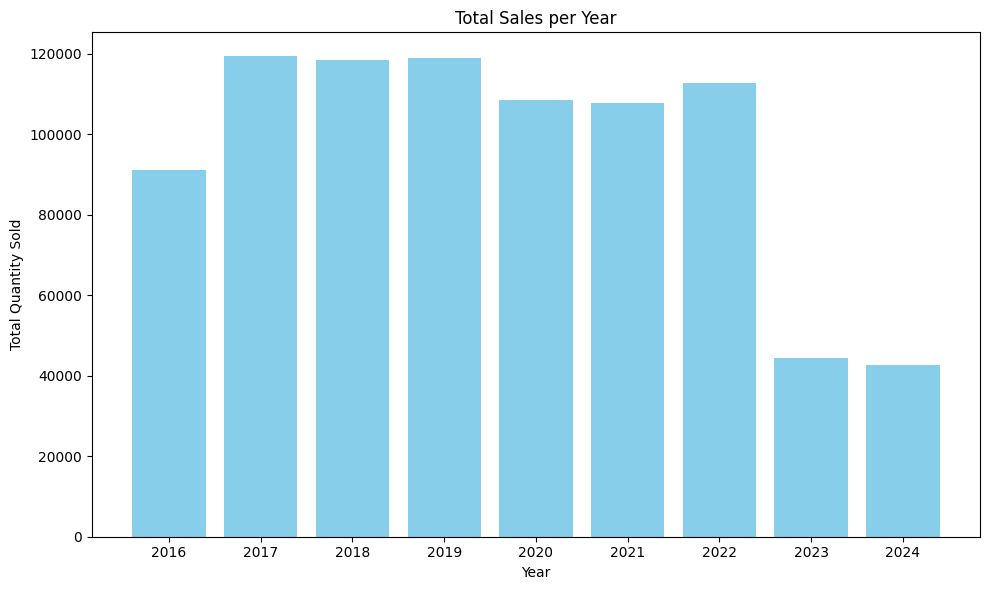

In [3]:
import matplotlib.pyplot as plt

# Total quantity sold per 3-month period
sales_by_period = df.groupby('Period_Start')['Quantity_Sold'].sum().reset_index()
print("Total Quantity Sold by 3-Month Period:\n")
print(sales_by_period.to_markdown(index=False, numalign="left", stralign="left"))

# Total quantity sold per year
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_sales = df.groupby('Year')['Quantity_Sold'].sum().reset_index()

# Plot yearly sales
plt.figure(figsize=(10, 6))
plt.bar(yearly_sales['Year'], yearly_sales['Quantity_Sold'], color='skyblue')
plt.title('Total Sales per Year')
plt.xlabel('Year')
plt.ylabel('Total Quantity Sold')
plt.xticks(yearly_sales['Year'])
plt.tight_layout()
plt.savefig("cell2_total_sales_year.png")




In [4]:
# Check and clean 'Material' column
print("Unique values in Material column before cleaning:\n", df['Material'].unique())
df['Material'] = df['Material'].str.strip().str.lower()
print("\nUnique values in Material column after cleaning:\n", df['Material'].unique())

# Summarize quantity sold per material for each 3-month period
material_sales = df.groupby(['Period_Start', 'Material'])['Quantity_Sold'].sum().reset_index()
material_pivot = material_sales.pivot(index='Period_Start', columns='Material', values='Quantity_Sold').fillna(0)

# Show the cleaned pivot table
print("\nMaterial Sales by 3-Month Period (Cleaned):\n")
print(material_pivot.to_markdown(numalign="left", stralign="left"))


Unique values in Material column before cleaning:
 ['Cotton' 'Silk' 'Chiffon' 'Rayon' 'Linen' 'Georgette' 'Wool' 'Pashmina'
 'Denim' 'Leather' ' Cotton' ' Linen' ' Chiffon' ' Silk' ' Rayon' ' Wool'
 ' Georgette' ' Satin' ' Velvet' ' Polyester' ' Denim' ' Lace' ' Lycra'
 ' Spandex' ' Faux Leather' 'Polyester']

Unique values in Material column after cleaning:
 ['cotton' 'silk' 'chiffon' 'rayon' 'linen' 'georgette' 'wool' 'pashmina'
 'denim' 'leather' 'satin' 'velvet' 'polyester' 'lace' 'lycra' 'spandex'
 'faux leather']

Material Sales by 3-Month Period (Cleaned):

| Period_Start   | chiffon   | cotton   | denim   | faux leather   | georgette   | lace   | leather   | linen   | lycra   | pashmina   | polyester   | rayon   | satin   | silk   | spandex   | velvet   | wool   |
|:---------------|:----------|:---------|:--------|:---------------|:------------|:-------|:----------|:--------|:--------|:-----------|:------------|:--------|:--------|:-------|:----------|:---------|:-------|
| 201

In [5]:
# Identify most sold material in each 3-month period
material_sales = df.groupby(['Period_Start', 'Material'])['Quantity_Sold'].sum().reset_index()
most_sold = material_sales.loc[material_sales.groupby('Period_Start')['Quantity_Sold'].idxmax()]
most_sold['Year'] = most_sold['Period_Start'].apply(lambda x: x.year)

# Print most sold materials year-wise
for year in range(2016, 2025):
    print(f"\nMost Sold Material Categories for {year}:\n")
    year_data = most_sold[most_sold['Year'] == year].copy()
    year_data['Period_Start'] = year_data['Period_Start'].apply(lambda x: x.strftime('%Y-%m-%d'))
    if year_data.empty:
        print("No data available for this year.")
    else:
        print(year_data[['Period_Start', 'Material']].to_markdown(index=False, numalign="left", stralign="left"))

        most_sold[['Period_Start', 'Material', 'Year']].to_excel("most_sold_materials_by_period.xlsx", index=False)
print("\n✅ Excel file 'most_sold_materials_by_period.xlsx' saved successfully.")



Most Sold Material Categories for 2016:

| Period_Start   | Material   |
|:---------------|:-----------|
| 2016-01-01     | wool       |
| 2016-04-01     | silk       |
| 2016-07-01     | polyester  |
| 2016-10-01     | silk       |

Most Sold Material Categories for 2017:

| Period_Start   | Material   |
|:---------------|:-----------|
| 2017-01-01     | cotton     |
| 2017-04-01     | cotton     |
| 2017-07-01     | linen      |
| 2017-10-01     | polyester  |

Most Sold Material Categories for 2018:

| Period_Start   | Material   |
|:---------------|:-----------|
| 2018-01-01     | cotton     |
| 2018-04-01     | cotton     |
| 2018-07-01     | cotton     |
| 2018-10-01     | silk       |

Most Sold Material Categories for 2019:

| Period_Start   | Material   |
|:---------------|:-----------|
| 2019-01-01     | wool       |
| 2019-04-01     | linen      |
| 2019-07-01     | linen      |
| 2019-10-01     | wool       |

Most Sold Material Categories for 2020:

| Period_Start   | Mat

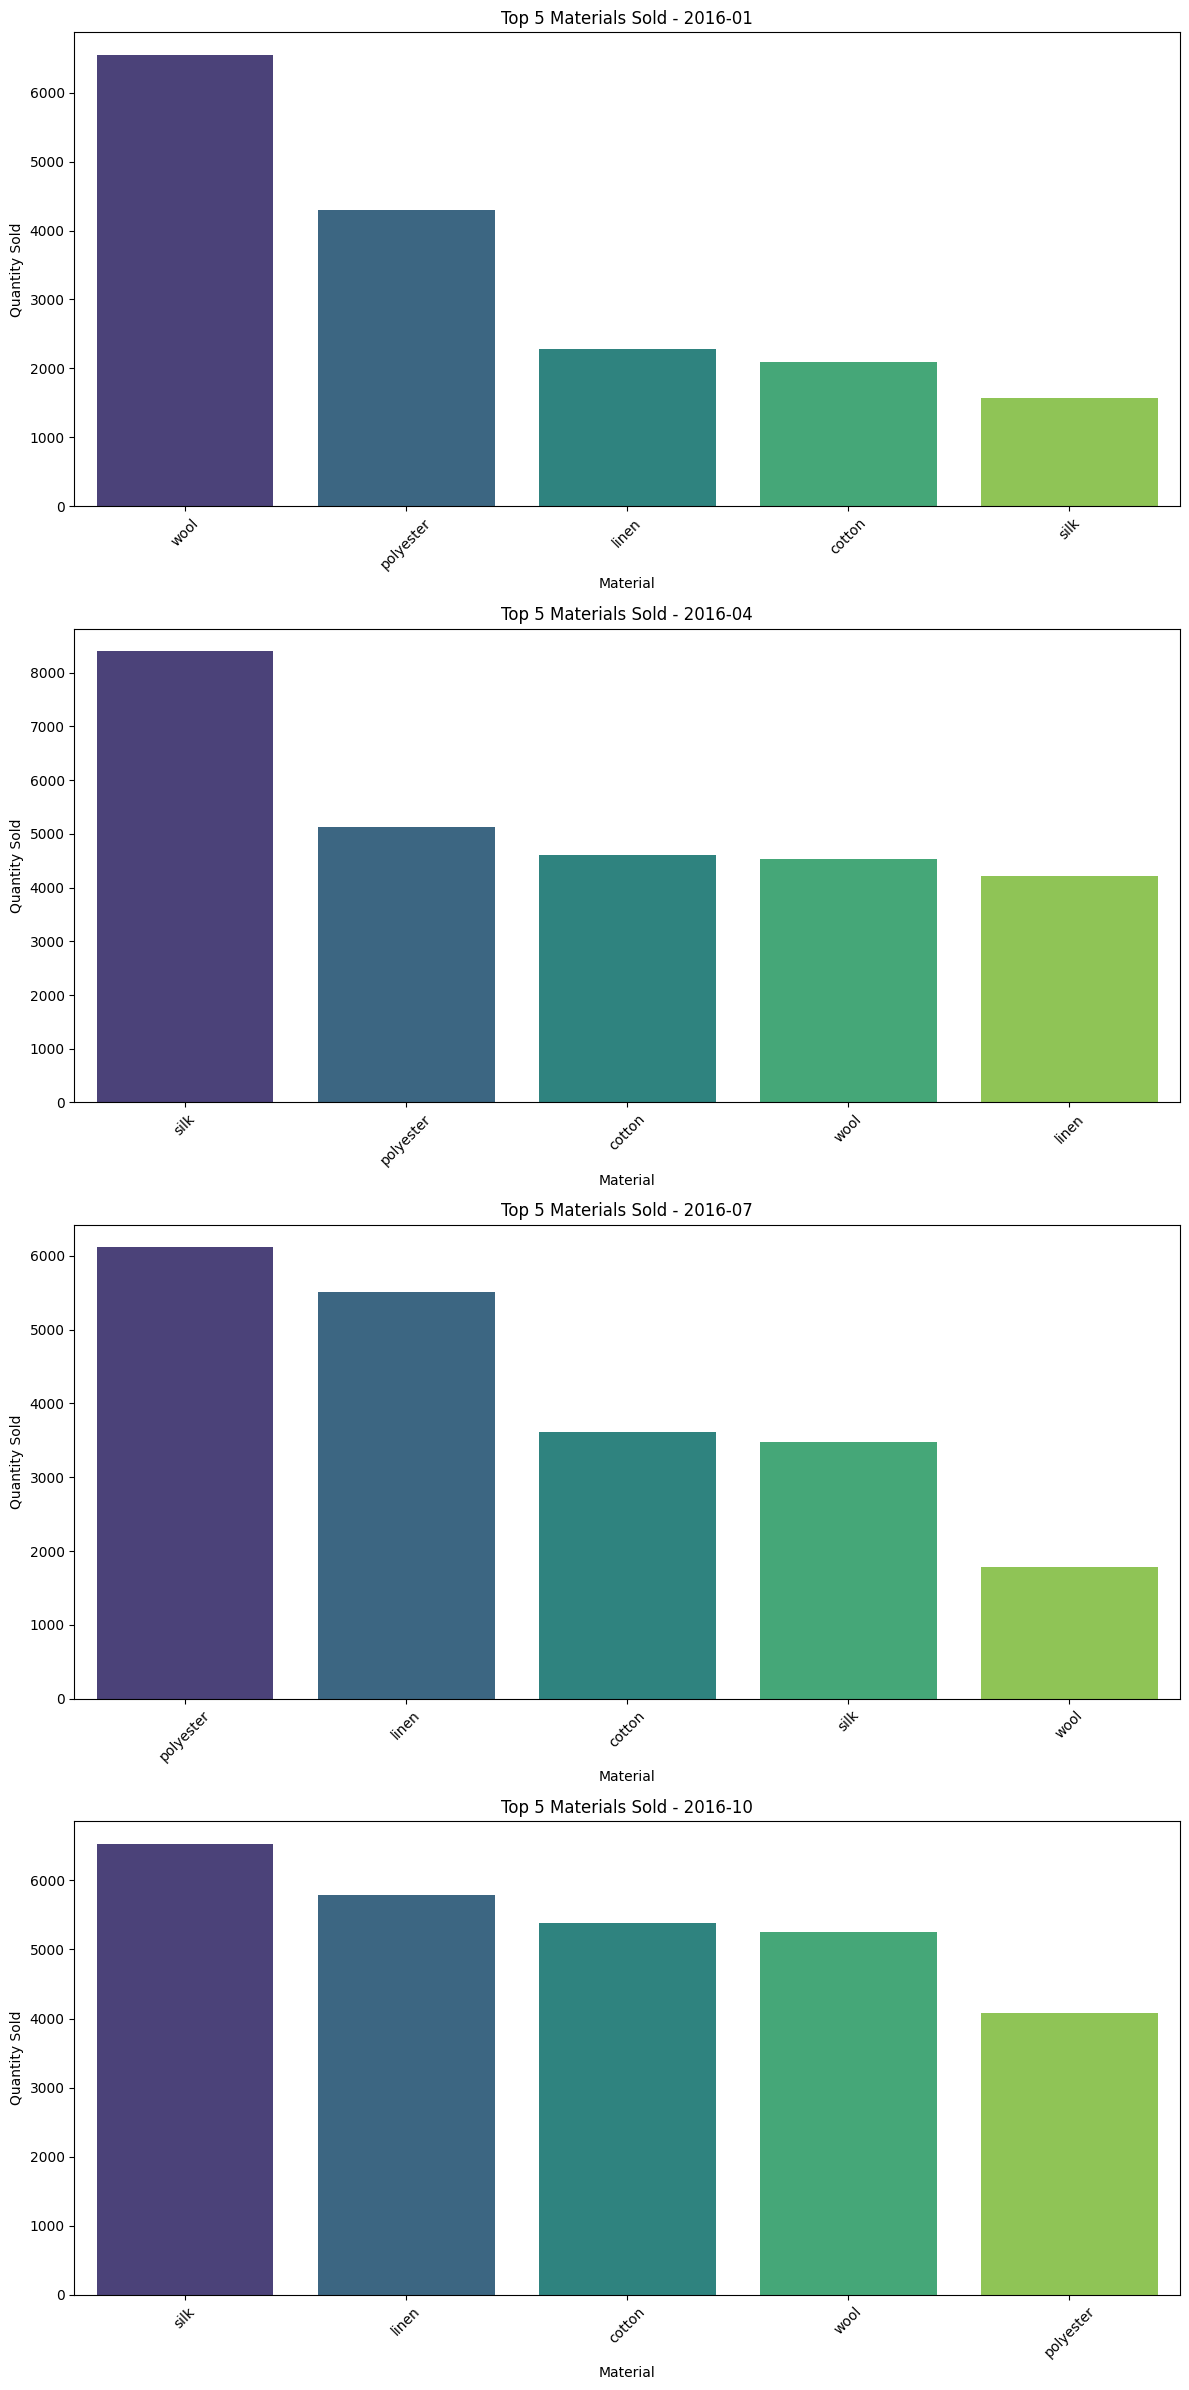

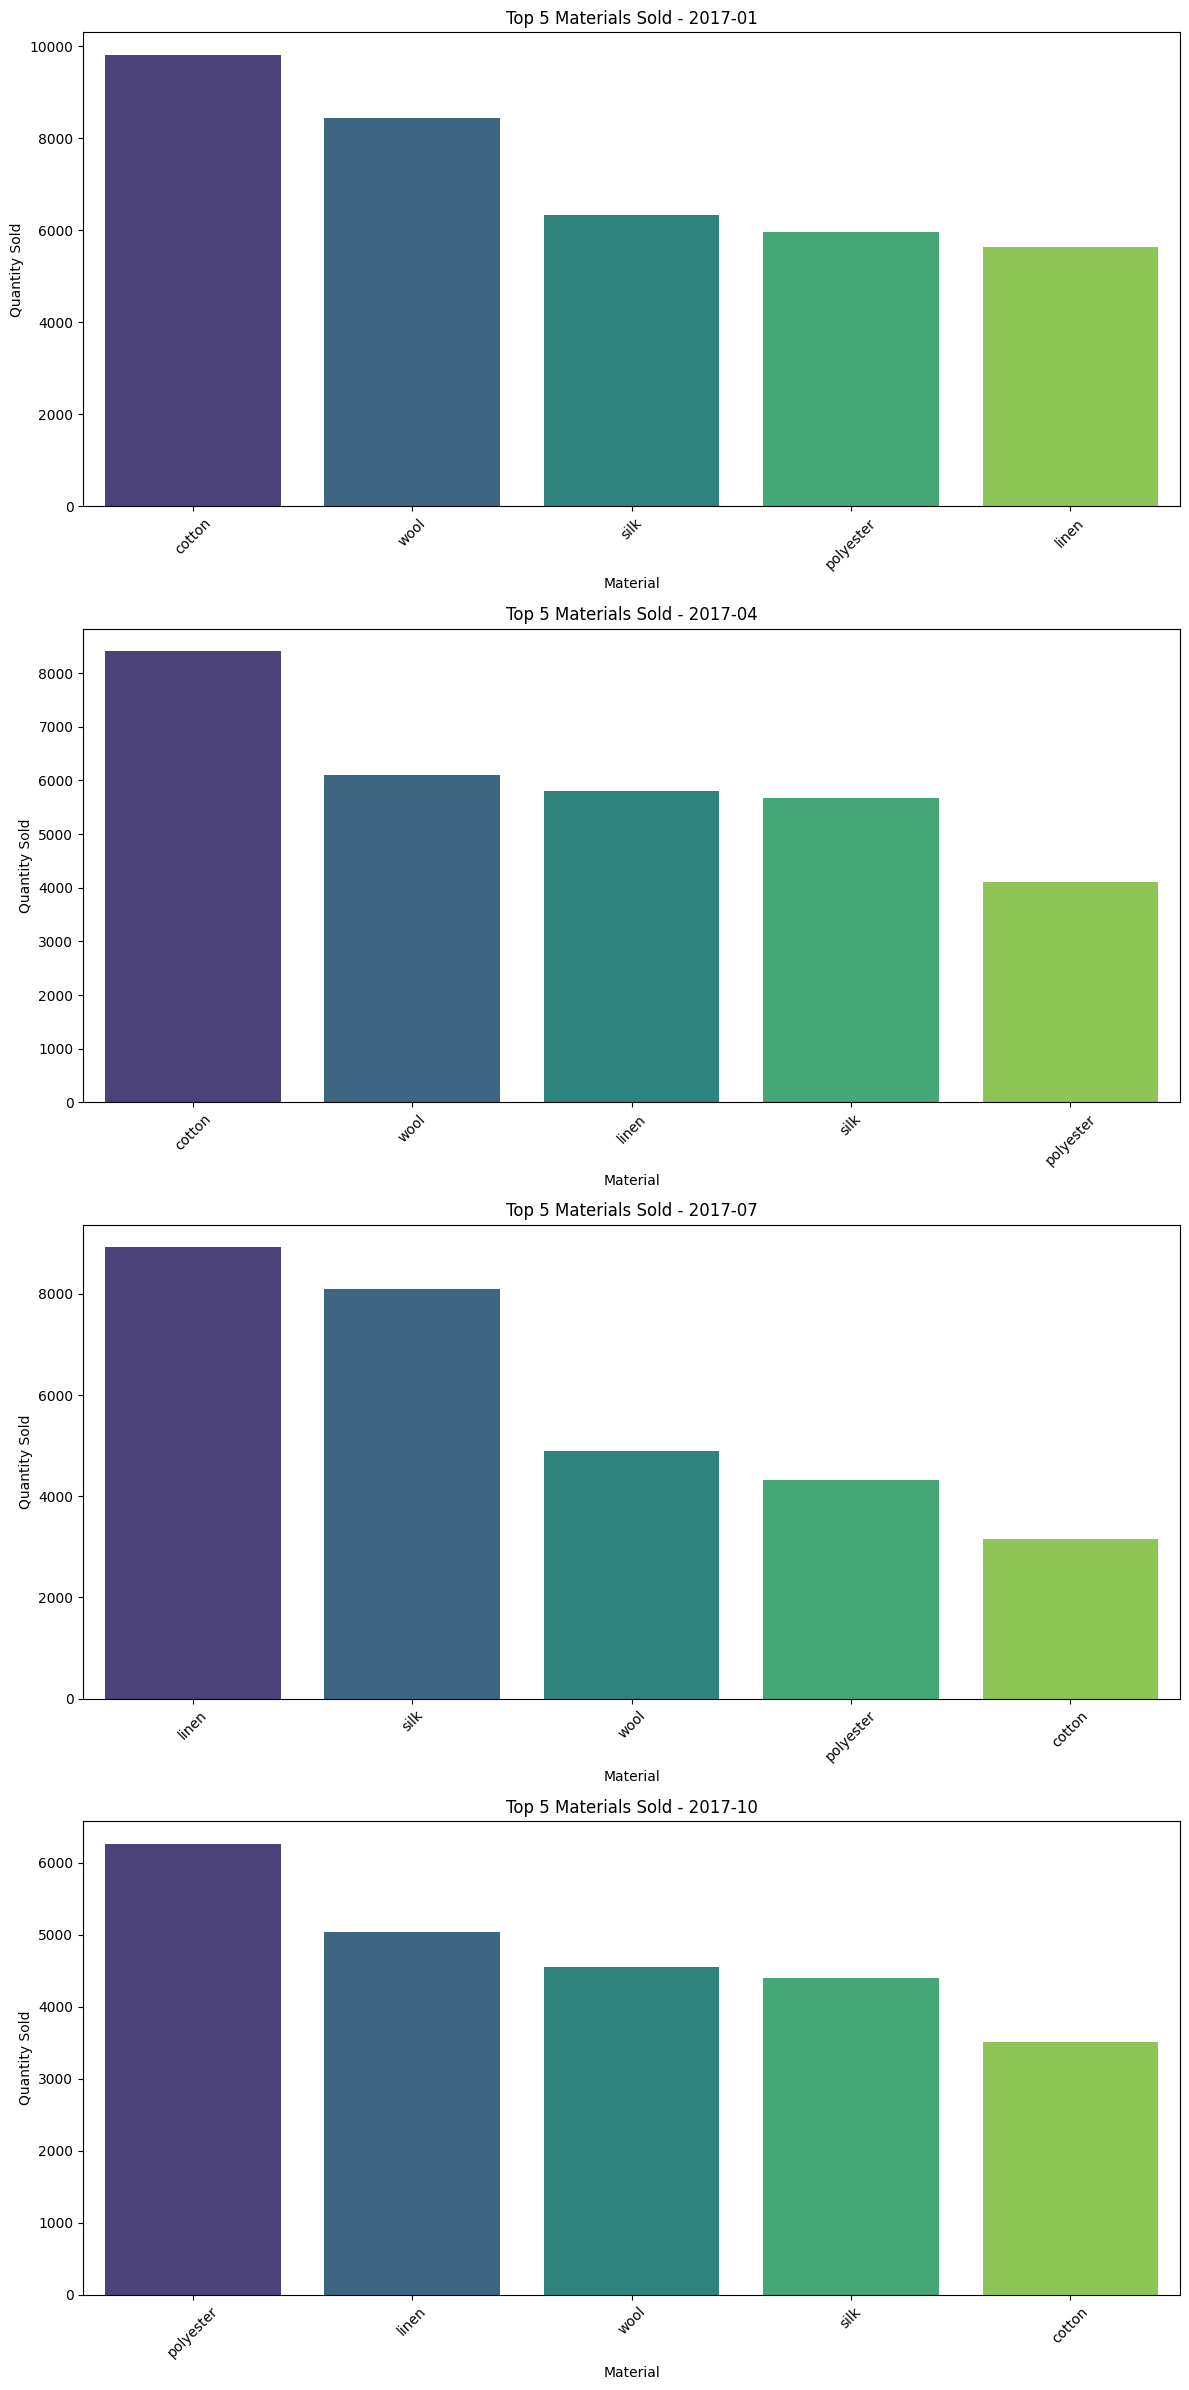

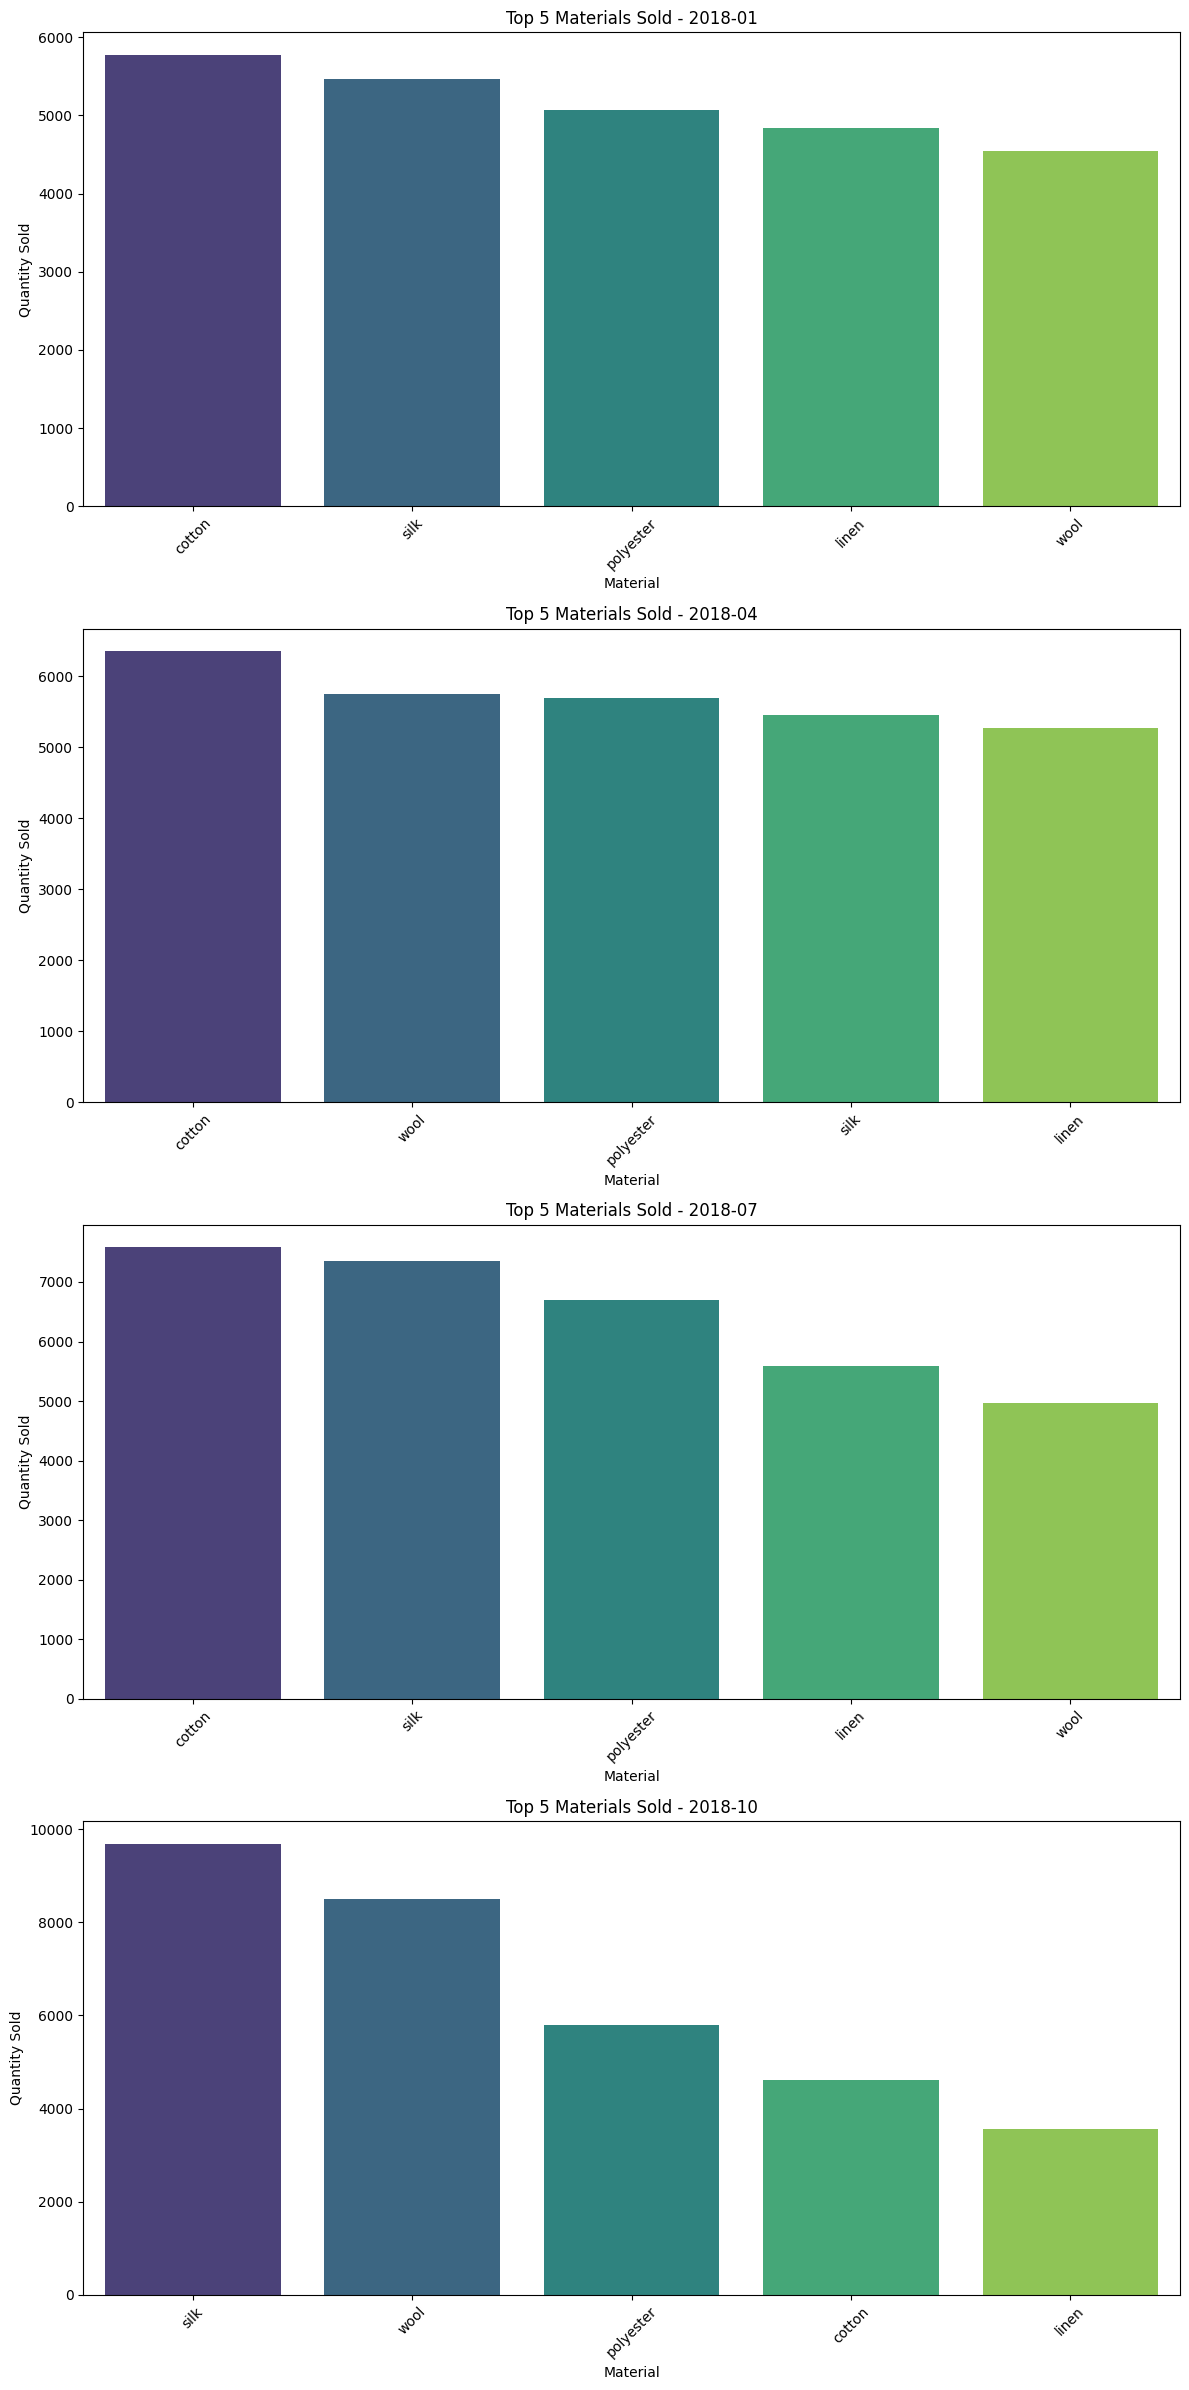

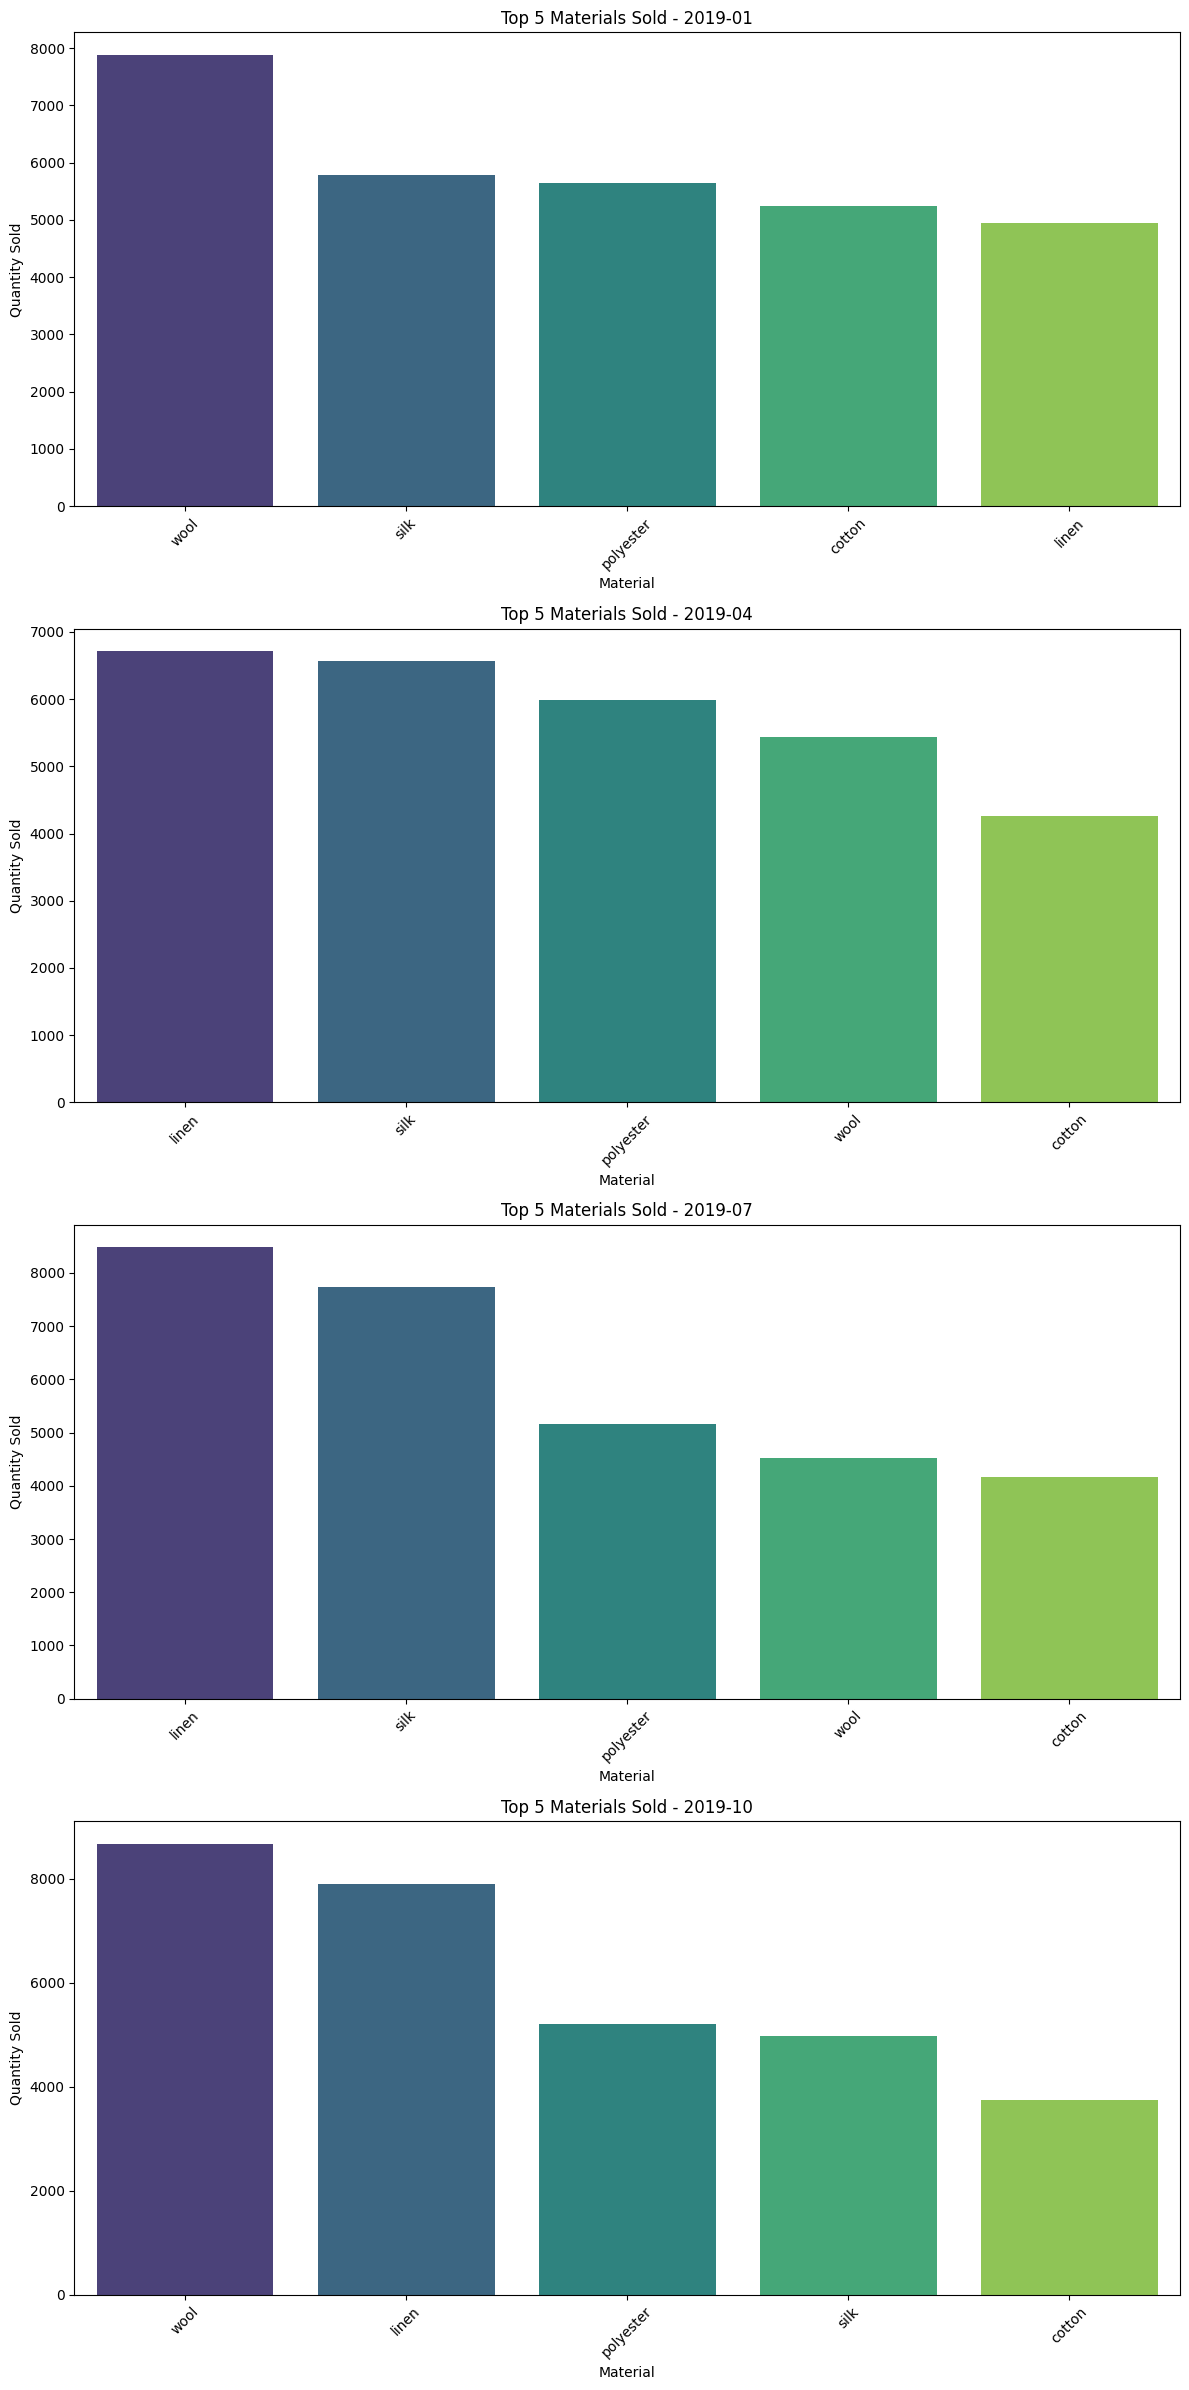

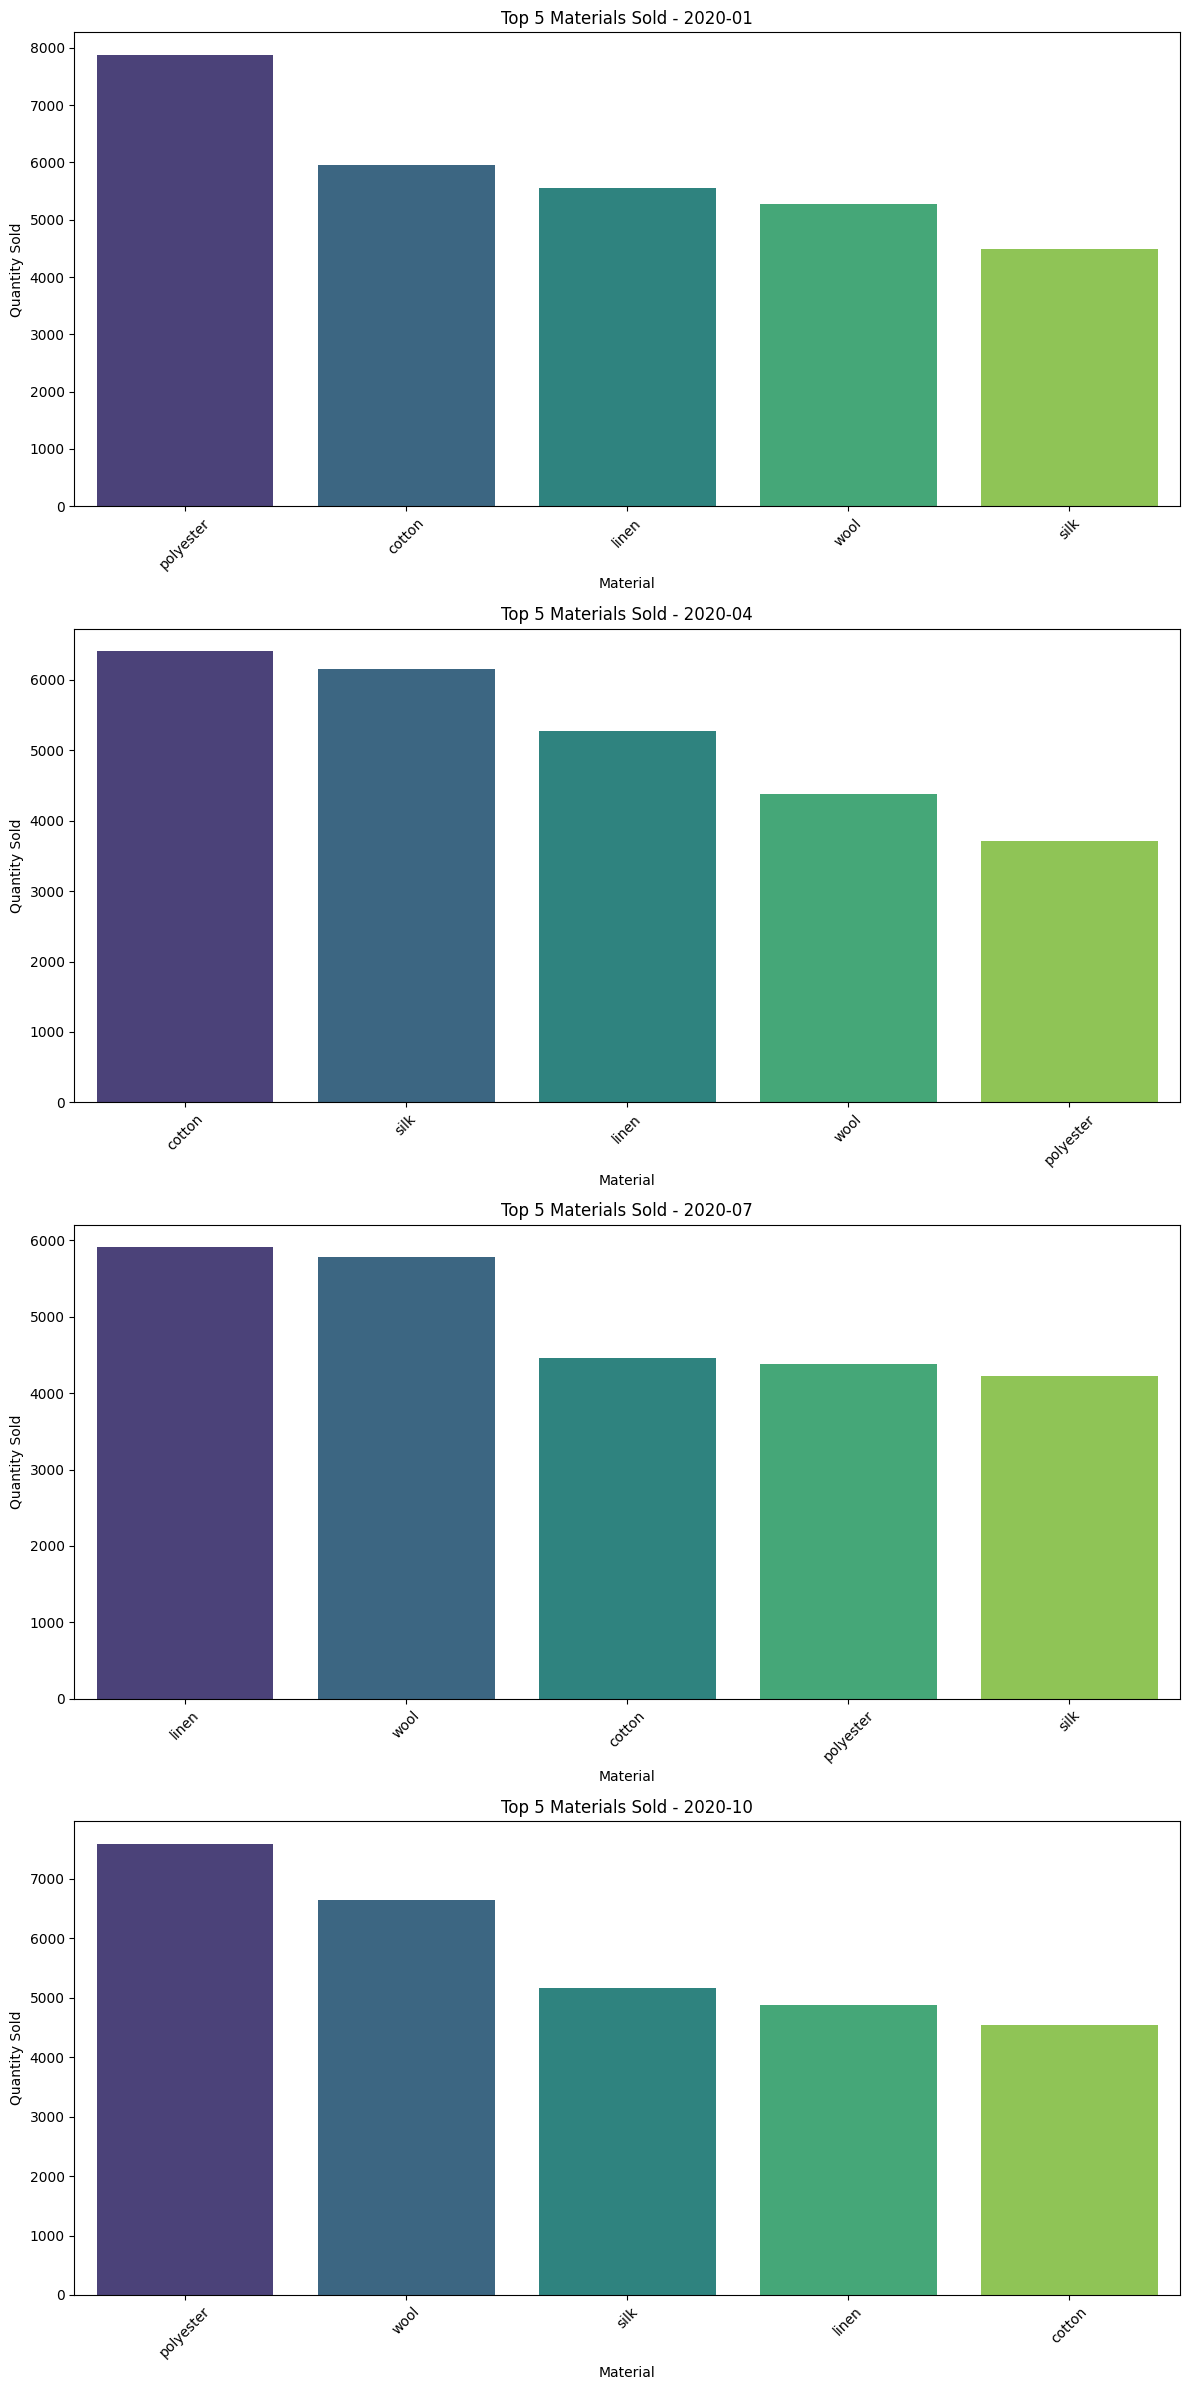

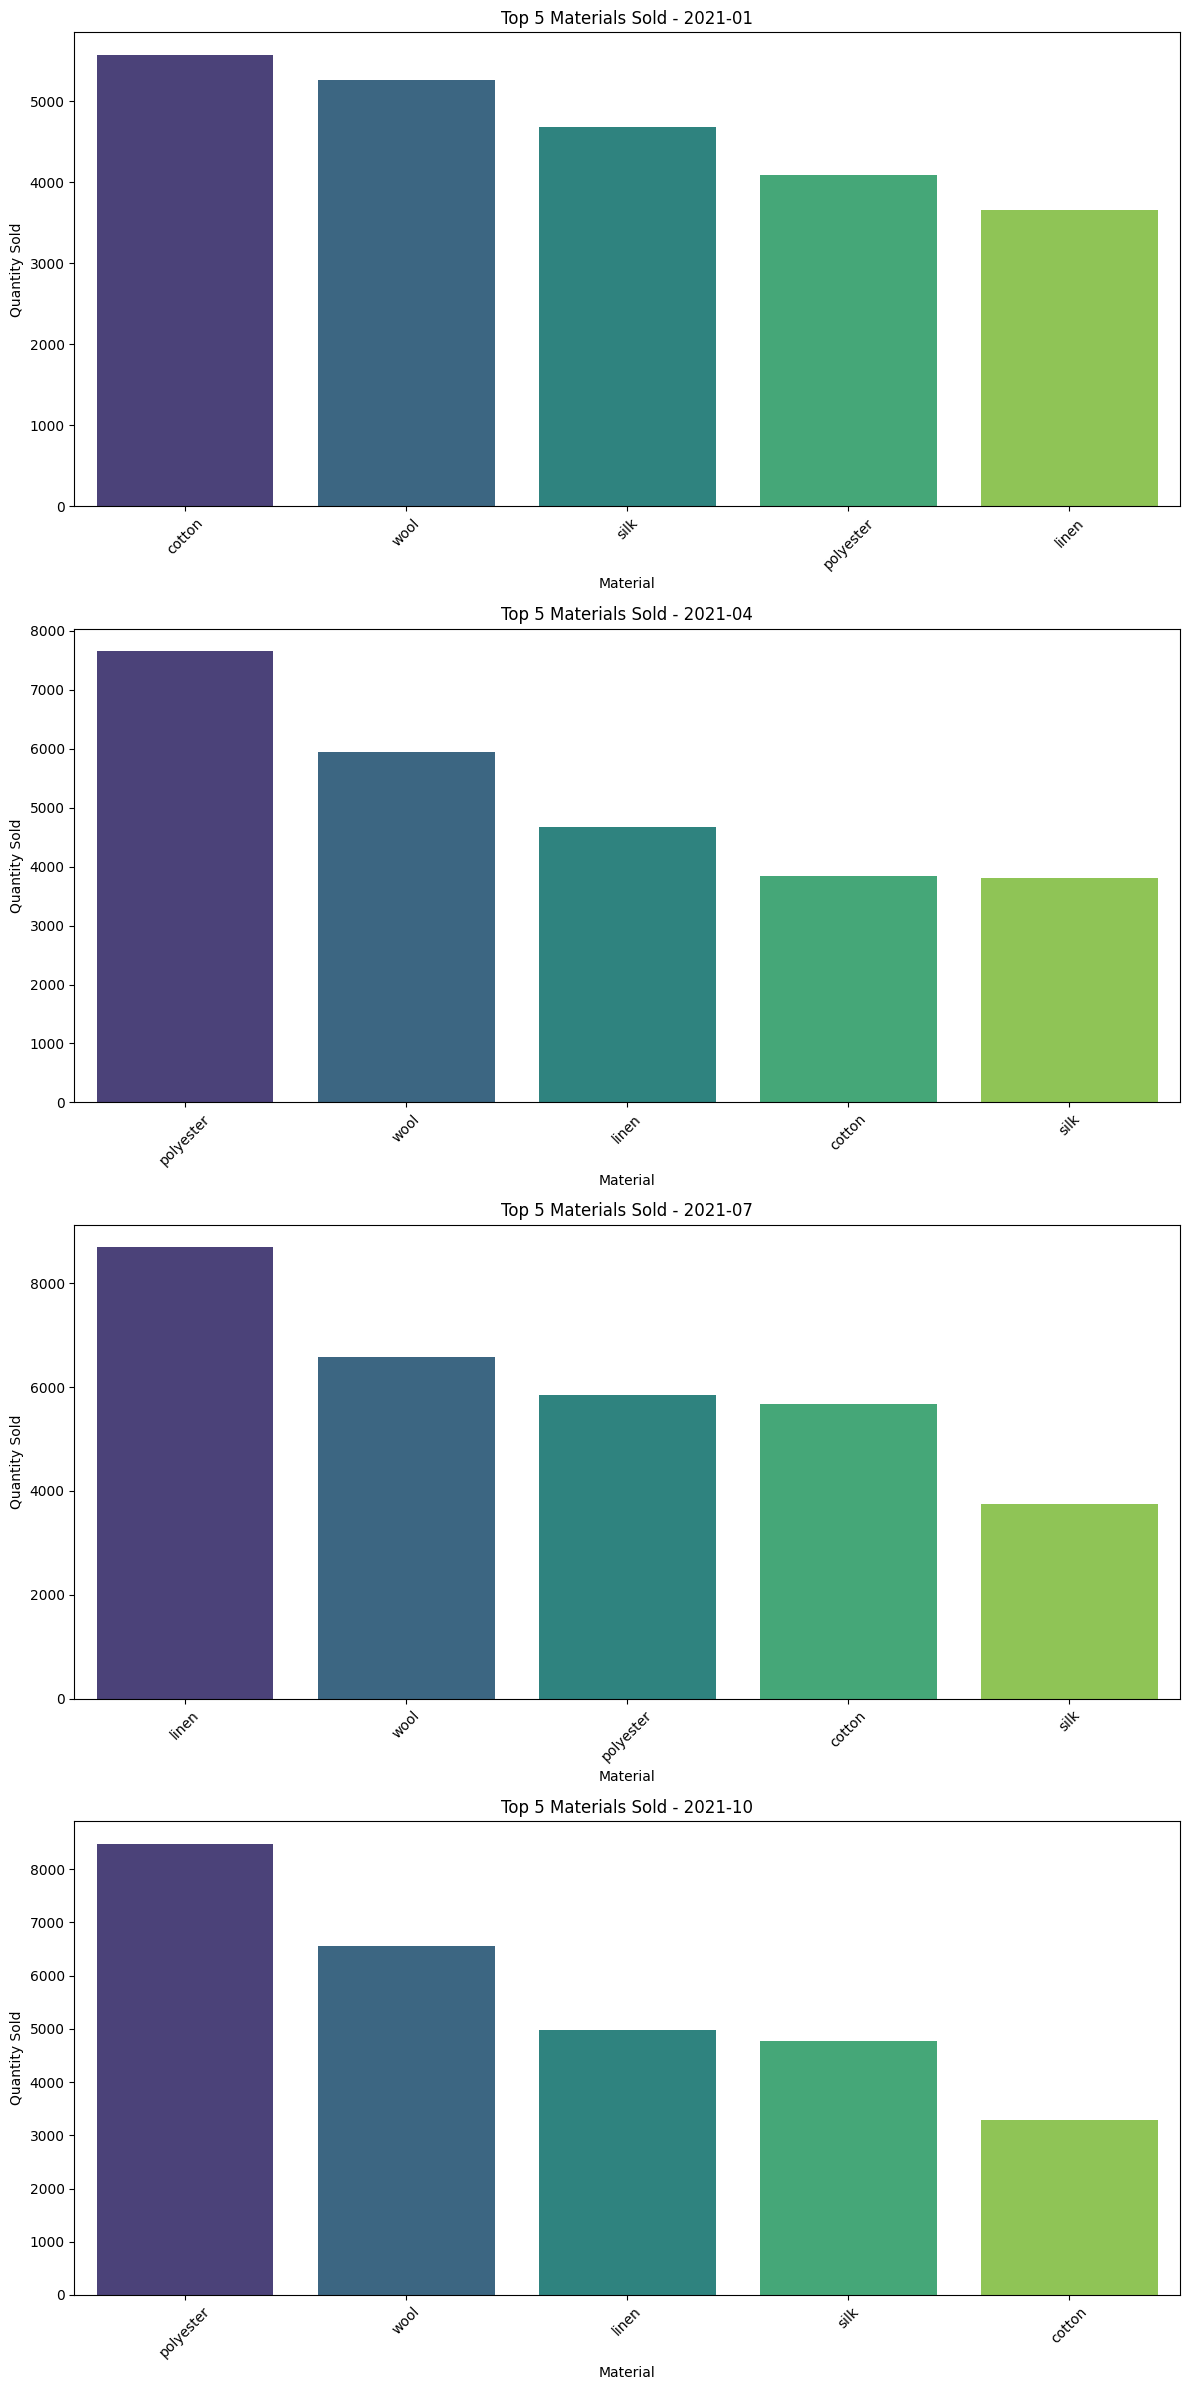

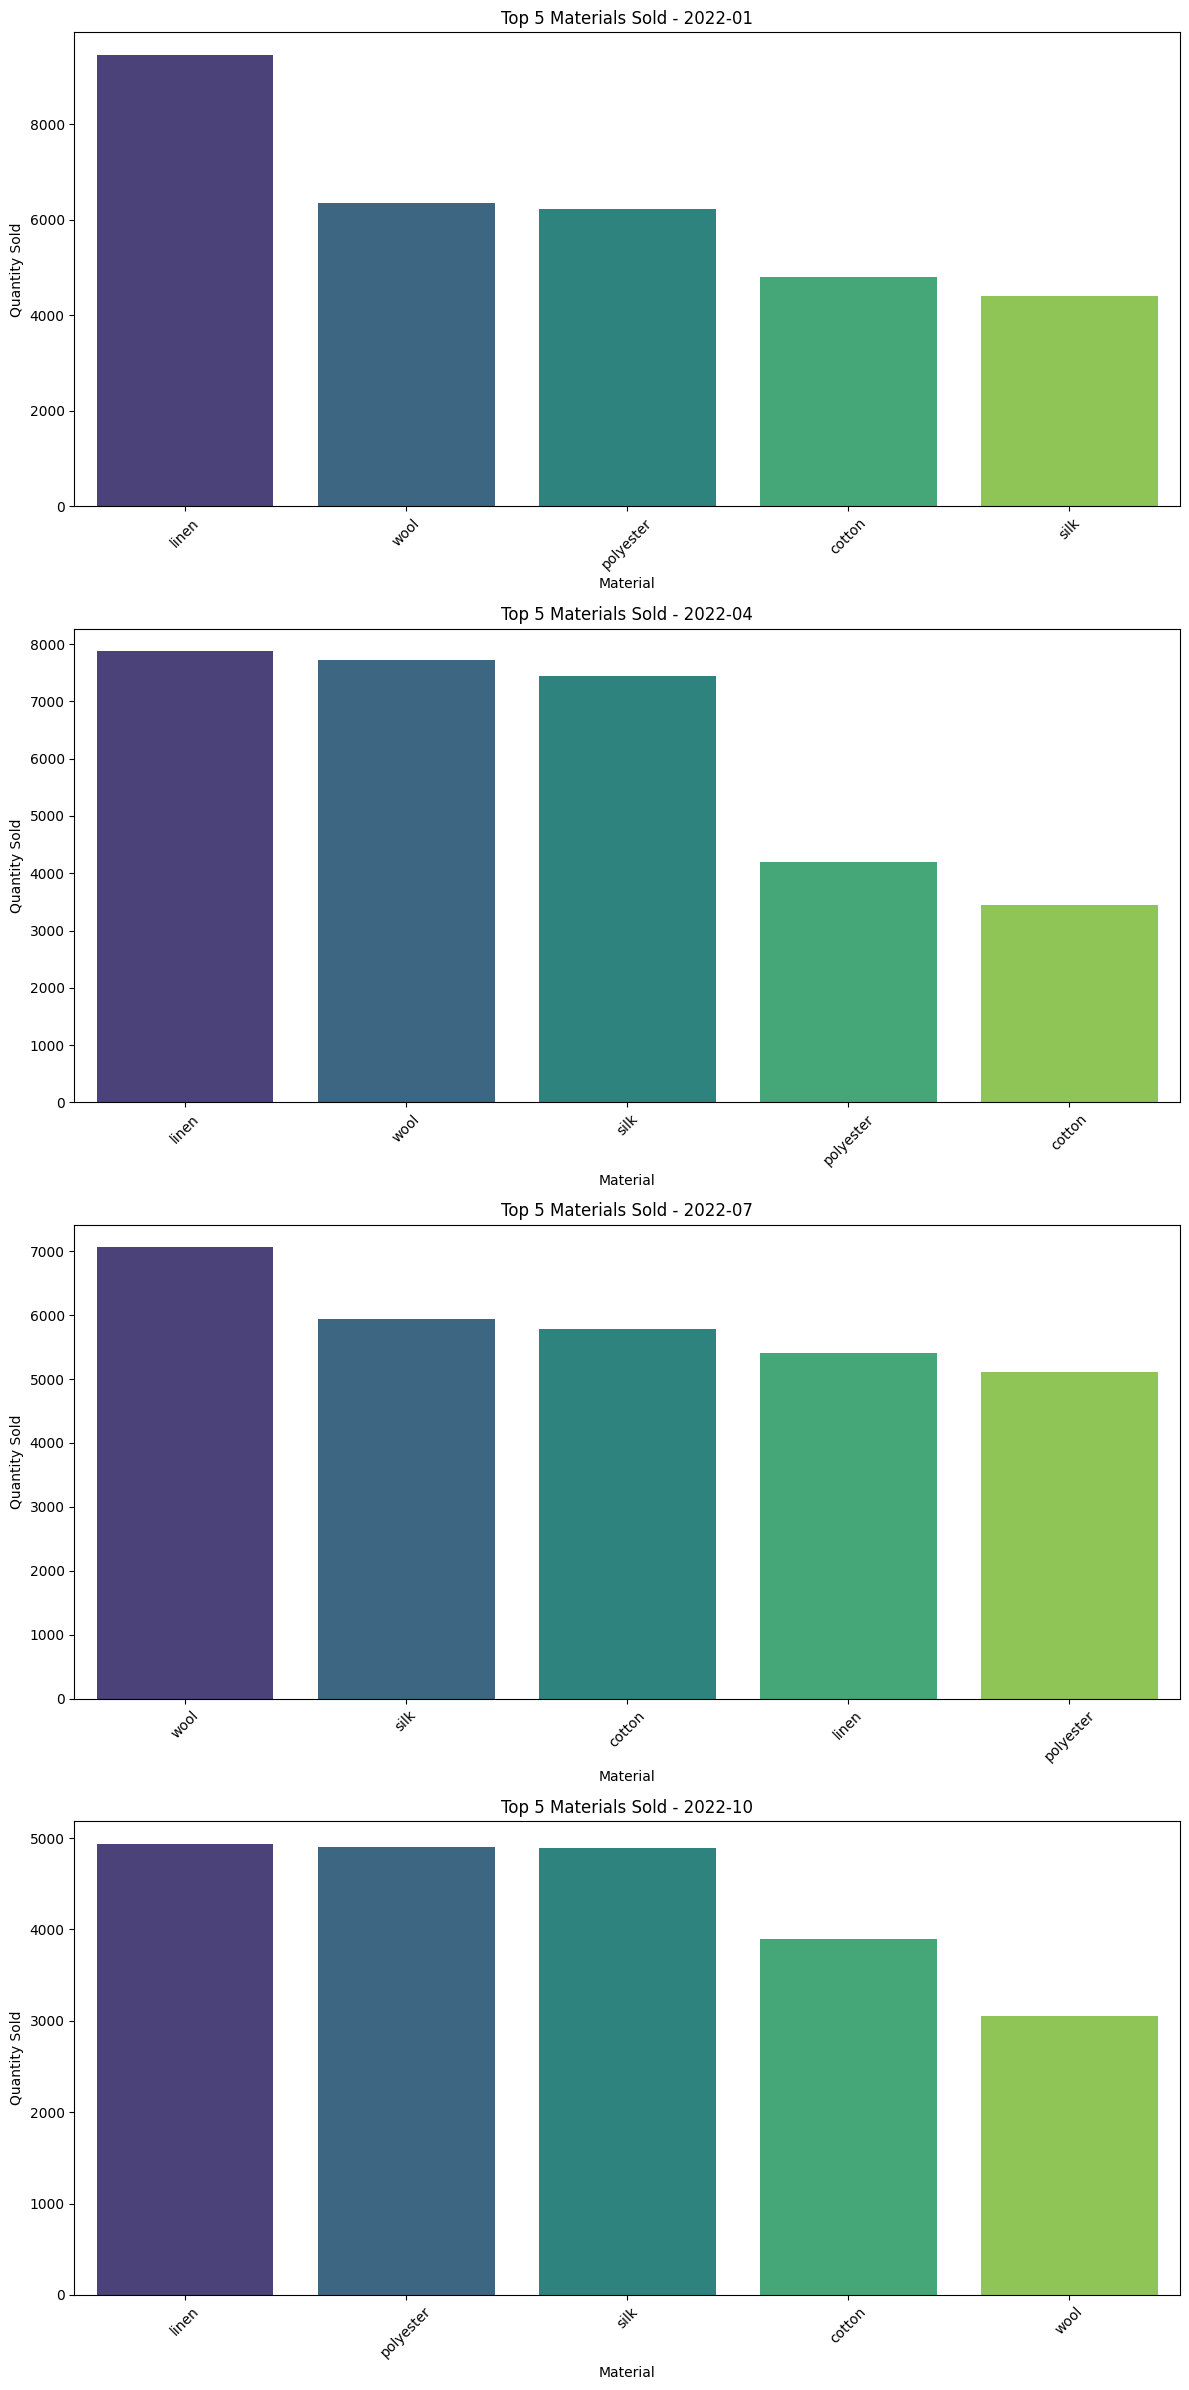

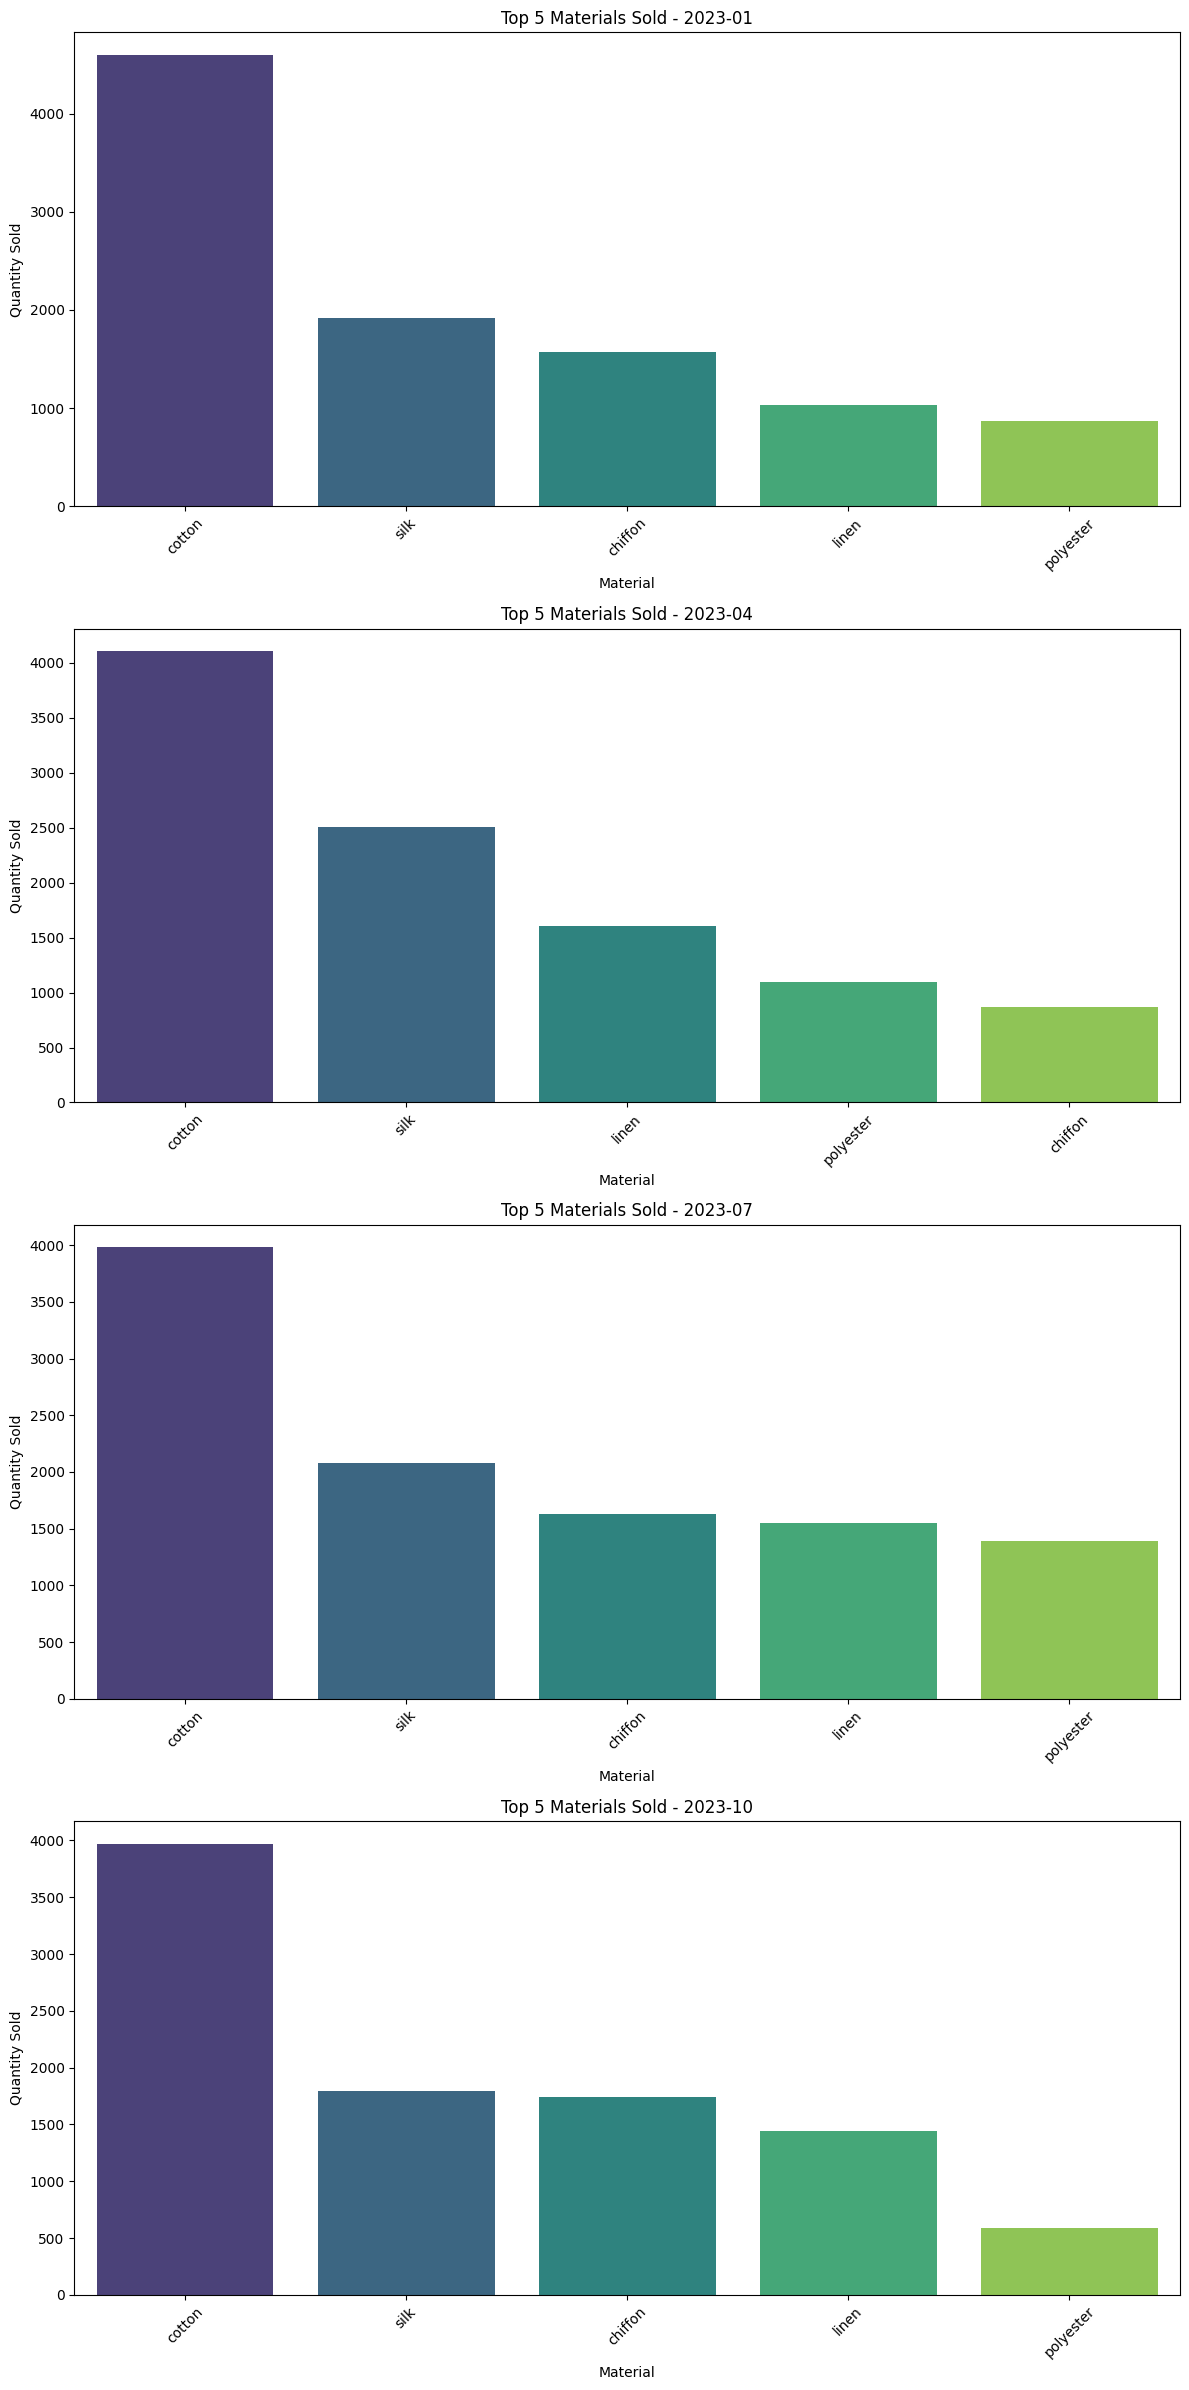

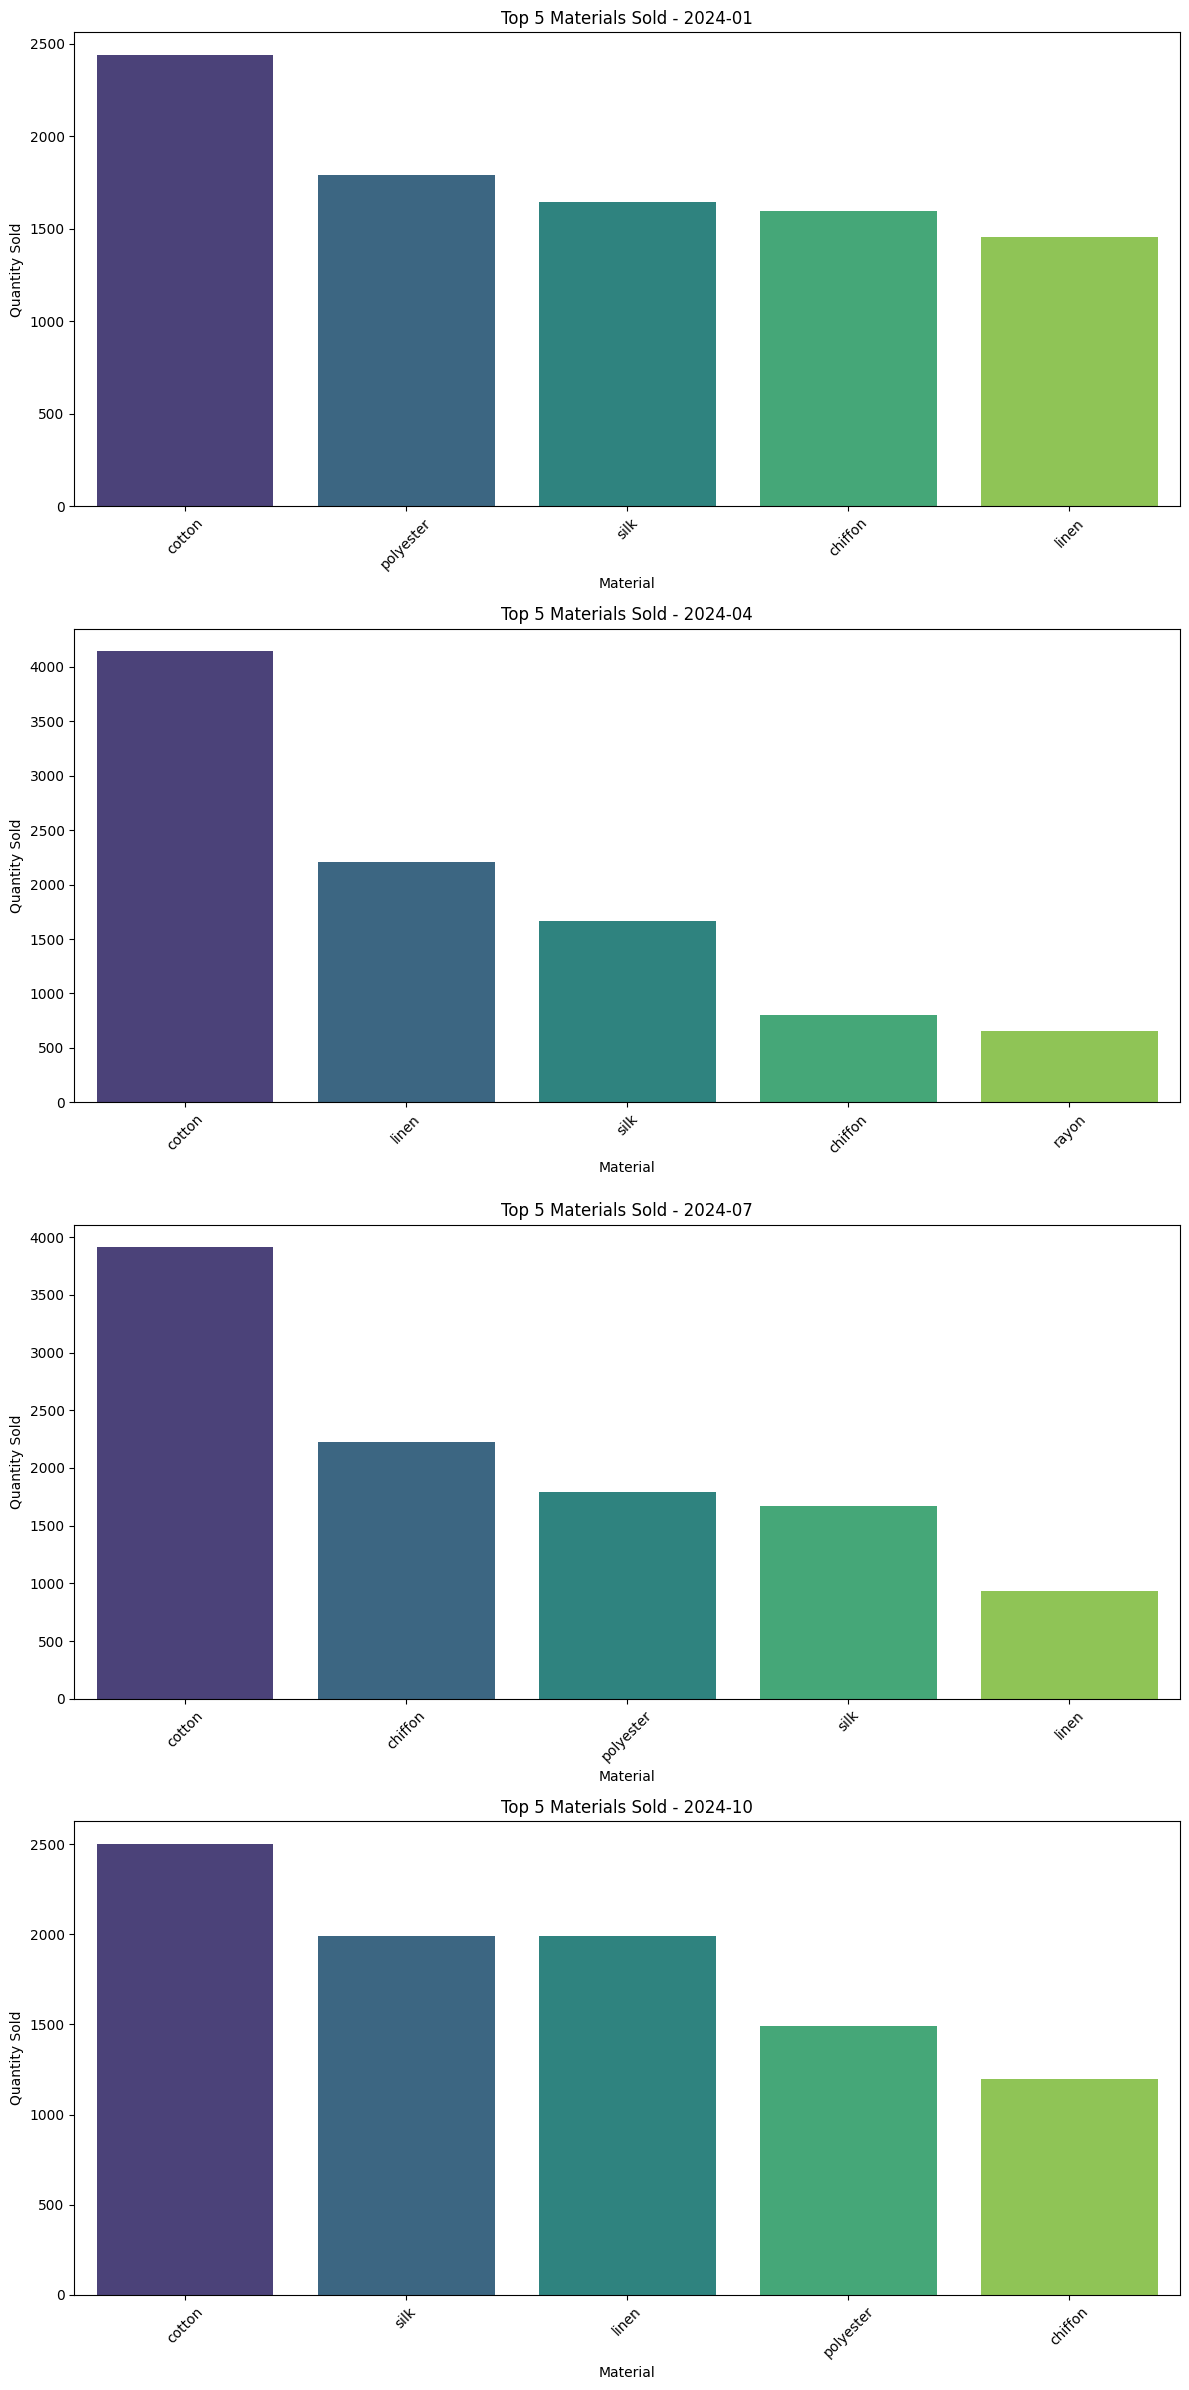

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Helper: Get top N materials by quantity sold
def get_top_n_materials(df_period, n=5):
    return df_period.groupby('Material')['Quantity_Sold'].sum().nlargest(n).index.tolist()

# Analyze and visualize top 5 materials per 3-month period, for each year
for year in range(2016, 2025):
    df_year = df[pd.to_datetime(df['Period_Start']).dt.year == year].copy()
    if df_year.empty:
        print(f"No data available for the year {year}")
        continue

    sales = df_year.groupby(['Period_Start', 'Material'])['Quantity_Sold'].sum().reset_index()
    periods = sales['Period_Start'].unique()

    fig, axes = plt.subplots(len(periods), 1, figsize=(12, 6 * len(periods)))
    axes = [axes] if len(periods) == 1 else axes  # Ensure iterable axes

    for i, period in enumerate(periods):
        period_data = sales[sales['Period_Start'] == period]
        top_materials = get_top_n_materials(period_data)
        top_sales = period_data[period_data['Material'].isin(top_materials)].sort_values(by='Quantity_Sold', ascending=False)

        sns.barplot(x='Material', y='Quantity_Sold', hue='Material', data=top_sales, ax=axes[i], palette='viridis', legend=False)
        axes[i].set_title(f"Top 5 Materials Sold - {pd.to_datetime(period).strftime('%Y-%m')}")
        axes[i].set_xlabel("Material")
        axes[i].set_ylabel("Quantity Sold")
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [7]:
# Identify most sold material per 3-month period
material_sales = df.groupby(['Period_Start', 'Material'])['Quantity_Sold'].sum().reset_index()
most_sold_material = material_sales.loc[material_sales.groupby('Period_Start')['Quantity_Sold'].idxmax()]
most_sold_material.rename(columns={'Material': 'Most_Sold_Material'}, inplace=True)

# Function: Get top 5 items for a given material within a period
def find_top_5_items(df_period):
    item_sales = df_period.groupby(['Item', 'Material'])['Quantity_Sold'].sum().reset_index()
    return item_sales.nlargest(5, 'Quantity_Sold')[['Item', 'Material', 'Quantity_Sold']]

# Function: Find top 5 items for the most sold material in a specific period
def get_top_items(group, period_start):
    row = most_sold_material[most_sold_material['Period_Start'] == period_start]
    if row.empty:
        return pd.DataFrame({'Period_Start': [period_start]})

    top_material = row['Most_Sold_Material'].iloc[0]
    filtered_group = group[group['Material'] == top_material]
    result = find_top_5_items(filtered_group)
    if not result.empty:
        result['Period_Start'] = period_start
    return result

# Apply to each group of periods
top_items_all = []
for period, group in df.groupby('Period_Start', group_keys=False):
    top_items_all.append(get_top_items(group, period))

top_5_items_by_period = pd.concat(top_items_all, ignore_index=True)

# Display results
print("\nTop 5 Items for Most Sold Material by 3-Month Period:\n")
for period in sorted(top_5_items_by_period['Period_Start'].unique()):
    print(f"\n--- Period: {pd.to_datetime(period).strftime('%Y-%m-%d')} ---")
    period_data = top_5_items_by_period[top_5_items_by_period['Period_Start'] == period].drop(columns='Period_Start')
    print(period_data.to_markdown(index=False, numalign="left", stralign="left") if not period_data.empty else "No data available for this period.")
#  Save to Excel
top_5_items_by_period.to_excel("top5_items_by_period.xlsx", index=False)
print("\n Excel file 'top5_items_by_period.xlsx' saved successfully.")


Top 5 Items for Most Sold Material by 3-Month Period:


--- Period: 2016-01-01 ---
| Item         | Material   | Quantity_Sold   |
|:-------------|:-----------|:----------------|
| Skirt        | wool       | 2309            |
| Cotton saree | wool       | 1335            |
| T-shirt      | wool       | 1182            |
| Blouse piece | wool       | 729             |
| Shirt        | wool       | 454             |

--- Period: 2016-04-01 ---
| Item         | Material   | Quantity_Sold   |
|:-------------|:-----------|:----------------|
| Shirt        | silk       | 1241            |
| Skirt        | silk       | 1212            |
| Blouse piece | silk       | 1045            |
| T-shirt      | silk       | 1019            |
| Pants        | silk       | 960             |

--- Period: 2016-07-01 ---
| Item         | Material   | Quantity_Sold   |
|:-------------|:-----------|:----------------|
| Pants        | polyester  | 1599            |
| Churidhar    | polyester  | 1146          

In [8]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Clean and prepare data
df['Material'] = df['Material'].str.strip()
df['Period_Start'] = pd.to_datetime(df['Period_Start'])

# Aggregate total sales per period
total_sales = df.groupby('Period_Start')['Quantity_Sold'].sum().reset_index().set_index('Period_Start')
total_sales['month'] = total_sales.index.month
total_sales['year'] = total_sales.index.year

# Lag feature creator
def create_lagged_features(data, n_lags=3):
    for i in range(1, n_lags + 1):
        data[f'y_lag_{i}'] = data['Quantity_Sold'].shift(i)
    return data.dropna()

# Prepare lagged features for total sales
df_lagged = create_lagged_features(total_sales.copy(), n_lags=3)

if len(df_lagged) < 2:
    print("Insufficient data for training and evaluation.")
else:
    X = df_lagged[['month', 'year', 'y_lag_1', 'y_lag_2', 'y_lag_3']]
    y = df_lagged['Quantity_Sold']

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
    ])

    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [3, 4, 5],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__colsample_bytree': [0.7, 0.8],
        'model__subsample': [0.7, 0.8]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    grid_search = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='r2', verbose=1, n_jobs=-1)
    grid_search.fit(X, y)

    best_model = grid_search.best_estimator_
    print("Best parameters:", grid_search.best_params_)

    # Model evaluation
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    y_pred = best_model.predict(X_test)
    print(f"Overall Model R² Score: {r2_score(y_test, y_pred):.4f}")

    # Forecast total sales for next 3-month period
    last_date = total_sales.index[-1]
    next_date = last_date + pd.DateOffset(months=3)
    last_sales = total_sales['Quantity_Sold'].tail(3).tolist()
    next_input = pd.DataFrame({
        'month': [next_date.month],
        'year': [next_date.year],
        'y_lag_1': [last_sales[2]],
        'y_lag_2': [last_sales[1]],
        'y_lag_3': [last_sales[0]]
    })
    next_forecast = best_model.predict(next_input)[0]
    print(f"\nForecast for total material sales in next 3 months ({next_date.strftime('%Y-%m-%d')}): {next_forecast:.2f}")

    # Forecasting per material
    material_predictions = {}
    for material in df['Material'].unique():
        mat_df = df[df['Material'] == material].groupby('Period_Start')['Quantity_Sold'].sum().reset_index()
        mat_df = mat_df.sort_values(by='Period_Start').set_index('Period_Start')
        if len(mat_df) < 4:
            print(f"Insufficient data for material {material}. Skipping.")
            continue

        mat_df['month'] = mat_df.index.month
        mat_df['year'] = mat_df.index.year
        mat_lagged = create_lagged_features(mat_df.copy(), n_lags=3)

        if len(mat_lagged) <= 3:
            print(f"Insufficient data for material {material} after lagging. Skipping.")
            continue

        X_mat = mat_lagged[['month', 'year', 'y_lag_1', 'y_lag_2', 'y_lag_3']]
        y_mat = mat_lagged['Quantity_Sold']

        tscv_mat = TimeSeriesSplit(n_splits=3)
        if len(X_mat) <= tscv_mat.n_splits:
            print(f"Insufficient data for material {material} for cross-validation. Skipping.")
            continue

        pipeline_mat = Pipeline([
            ('scaler', StandardScaler()),
            ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
        ])

        param_grid_mat = {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 4],
            'model__learning_rate': [0.01, 0.05],
            'model__colsample_bytree': [0.7, 0.8],
            'model__subsample': [0.7, 0.8]
        }

        grid_search_mat = GridSearchCV(pipeline_mat, param_grid_mat, cv=tscv_mat, scoring='r2', verbose=0, n_jobs=-1)
        grid_search_mat.fit(X_mat, y_mat)
        best_model_mat = grid_search_mat.best_estimator_

        # Forecast for next period
        last_date_mat = mat_df.index[-1]
        next_date_mat = last_date_mat + pd.DateOffset(months=3)
        last_sales_mat = mat_df['Quantity_Sold'].tail(3).tolist()
        next_input_mat = pd.DataFrame({
            'month': [next_date_mat.month],
            'year': [next_date_mat.year],
            'y_lag_1': [last_sales_mat[2]],
            'y_lag_2': [last_sales_mat[1]],
            'y_lag_3': [last_sales_mat[0]]
        })

        prediction = best_model_mat.predict(next_input_mat)[0]
        material_predictions[material] = prediction

    # Display sorted forecasts
    print("\nPredicted Material Sales for the Next 3 Months (High to Low):")
    print("------------------------------------------------------------")
    print("{:<10} {:>15}".format("Material", "Predicted Sales"))
    print("------------------------------------------------------------")
    for material, forecast in sorted(material_predictions.items(), key=lambda x: x[1], reverse=True):
        print("{:<10} {:>15.2f}".format(material, forecast))

# Save sorted material predictions to Excel
import pandas as pd

# Sort material predictions (already calculated in your code)
sorted_material_predictions = sorted(material_predictions.items(), key=lambda x: x[1], reverse=True)

# Convert to DataFrame
forecast_df = pd.DataFrame(sorted_material_predictions, columns=["Material", "Predicted_Sales"])

# Save to Excel file
forecast_df.to_excel("forecast_materials.xlsx", index=False)

print("\n✅ Forecast results saved to 'forecast_materials.xlsx'")



Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 0.7}
Overall Model R² Score: 0.9997

Forecast for total material sales in next 3 months (2025-01-01): 10960.14


/Users/mohamedharis/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/mohamedharis/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/mohamedharis/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/mohamedharis/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/mohamedharis/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regress

Insufficient data for material pashmina. Skipping.
Insufficient data for material denim after lagging. Skipping.
Insufficient data for material leather. Skipping.
Insufficient data for material satin after lagging. Skipping.
Insufficient data for material velvet. Skipping.
Insufficient data for material lace. Skipping.
Insufficient data for material lycra. Skipping.
Insufficient data for material spandex. Skipping.
Insufficient data for material faux leather. Skipping.

Predicted Material Sales for the Next 3 Months (High to Low):
------------------------------------------------------------
Material   Predicted Sales
------------------------------------------------------------
cotton             4444.66
linen              3075.74
silk               2392.84
wool               2118.18
chiffon            1608.40
polyester           952.53
rayon               474.82
georgette           171.31

✅ Forecast results saved to 'forecast_materials.xlsx'


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = best_model.predict(X_test)

# Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Overall Model R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 4.4916
Mean Squared Error (MSE): 60.2938
Root Mean Squared Error (RMSE): 7.7649
Overall Model R² Score: 0.9997


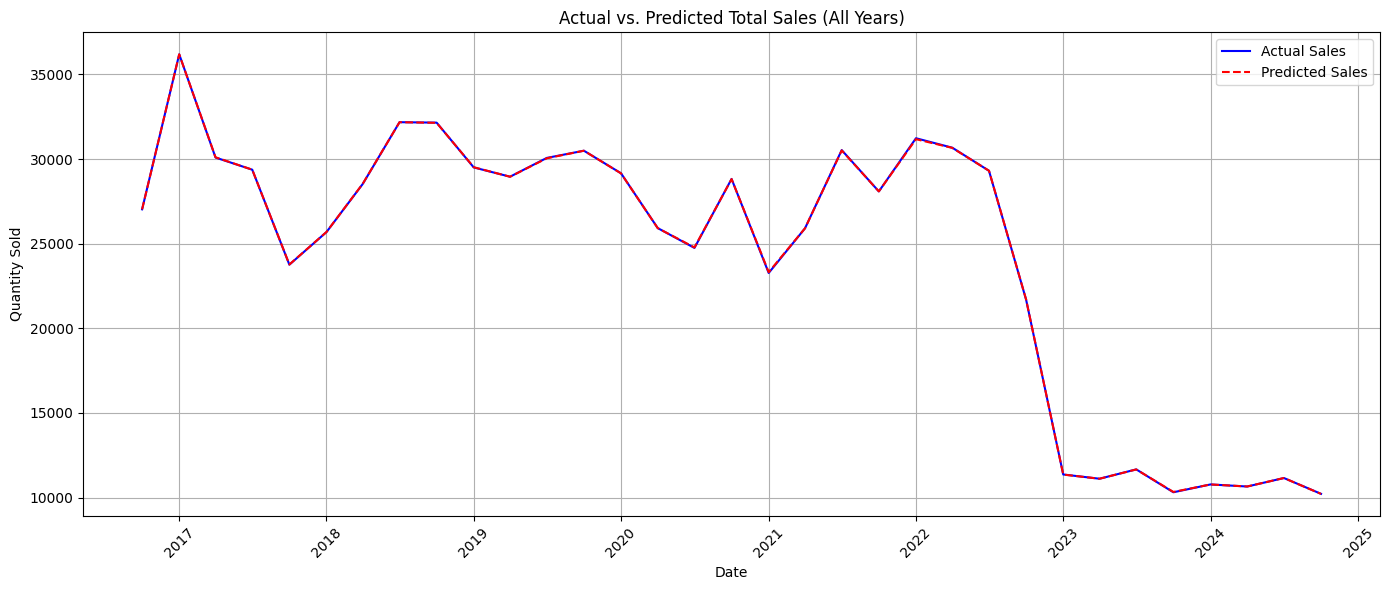

In [10]:
import matplotlib.pyplot as plt

# Predict for the full feature set
y_full_pred = best_model.predict(X)

# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(df_lagged.index, y, label='Actual Sales', color='blue')
plt.plot(df_lagged.index, y_full_pred, label='Predicted Sales', color='red', linestyle='--')

plt.title('Actual vs. Predicted Total Sales (All Years)')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


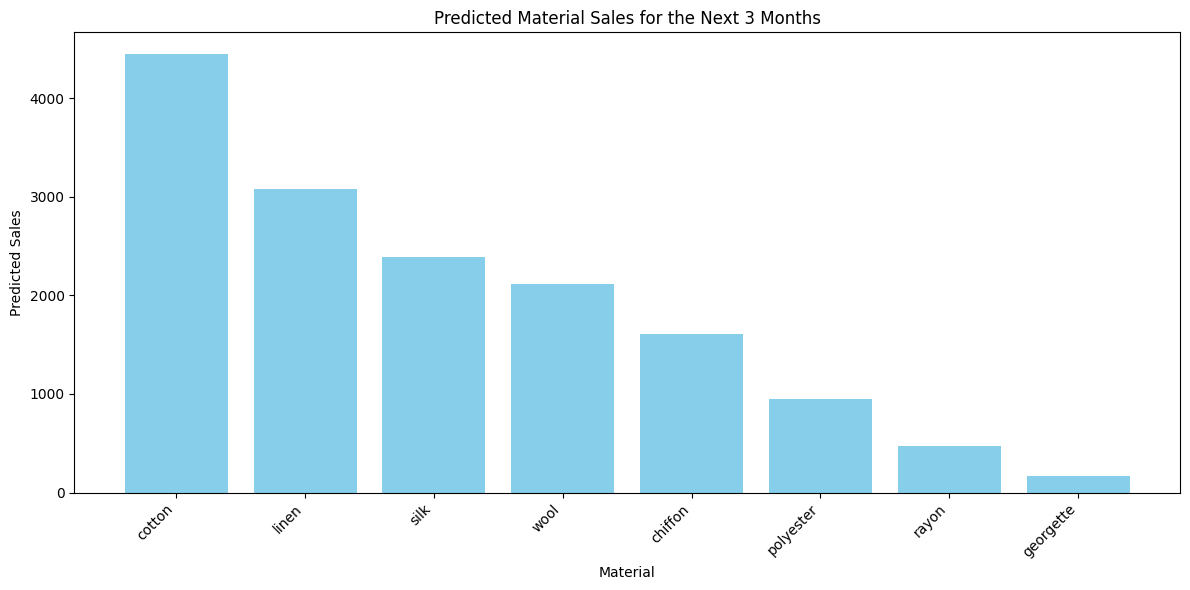

In [11]:
import matplotlib.pyplot as plt

# Sort the material predictions by predicted sales in descending order
sorted_material_predictions = sorted(material_predictions.items(), key=lambda item: item[1], reverse=True)

# Extract material names and corresponding predicted sales values
materials = [material for material, _ in sorted_material_predictions]
predictions = [sales for _, sales in sorted_material_predictions]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(materials, predictions, color='skyblue')

# Customize chart appearance
plt.title('Predicted Material Sales for the Next 3 Months')
plt.xlabel('Material')
plt.ylabel('Predicted Sales')
plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.tight_layout()  # Adjust layout to avoid label cutoff

# Display the chart
plt.savefig("cell13_forecast_xgboost.png")


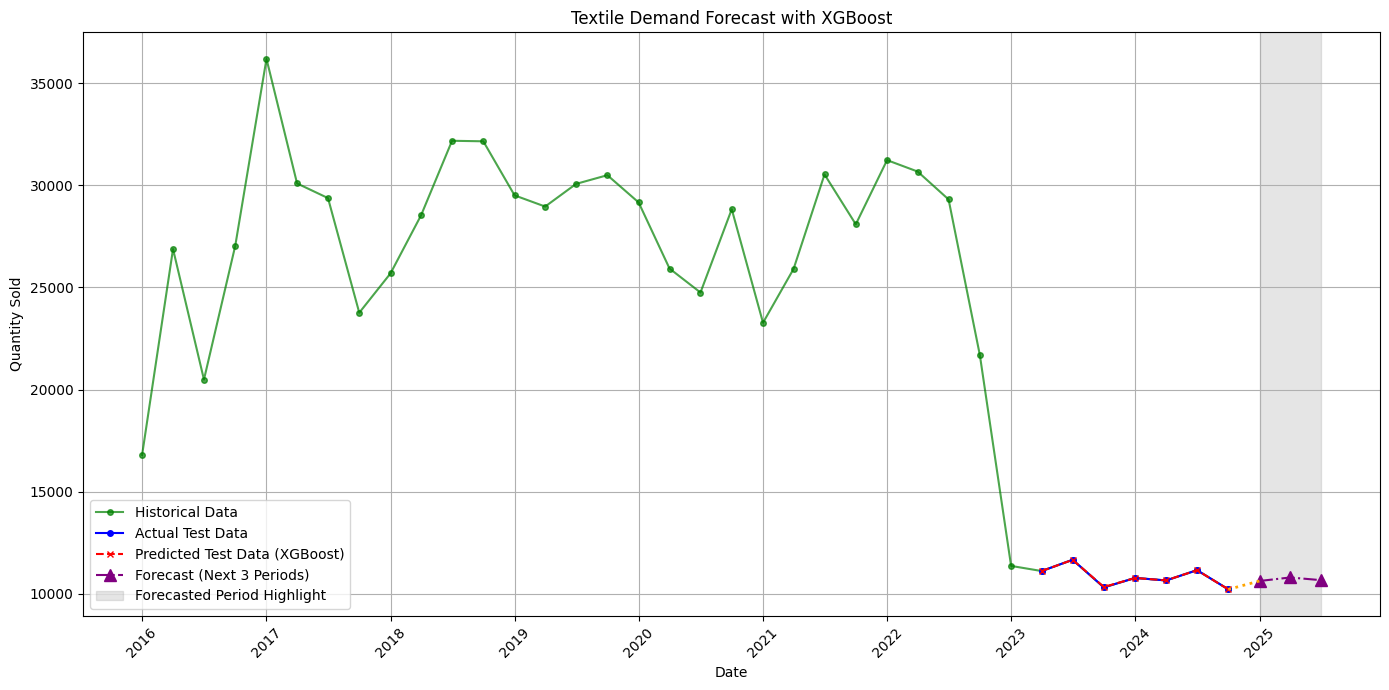

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create month/year and lag features
df['month'] = df['Period_Start'].dt.month
df['year'] = df['Period_Start'].dt.year
df = df.sort_values('Period_Start')
df['y_lag_1'] = df['Quantity_Sold'].shift(1)
df['y_lag_2'] = df['Quantity_Sold'].shift(2)
df['y_lag_3'] = df['Quantity_Sold'].shift(3)

# Prepare features for model prediction
df_model = df.dropna(subset=['y_lag_1', 'y_lag_2', 'y_lag_3'])
X_full = df_model[['month', 'year', 'y_lag_1', 'y_lag_2', 'y_lag_3']]

# Predict using the trained model
y_full_pred = best_model.predict(X_full)


#Prepare the total sales per 3-month period ---
# Ensure Period_Start is datetime
df['Period_Start'] = pd.to_datetime(df['Period_Start'])

# Group by Period_Start and sum Quantity_Sold
total_sales_per_period = df.groupby('Period_Start')['Quantity_Sold'].sum().reset_index()

# Set index for time series plotting
total_sales_per_period = total_sales_per_period.set_index('Period_Start')

#Plot Historical, Test, Predicted, and Forecasted Sales ---
plt.figure(figsize=(14, 7))

# Plot Historical Sales
plt.plot(
    total_sales_per_period.index,
    total_sales_per_period['Quantity_Sold'],
    label='Historical Data',
    color='green',
    marker='o',
    linestyle='-',
    alpha=0.7,
    markersize=4
)

# Plot Actual Test Data
if 'y_test' in locals() and len(y_test) > 0:
    plt.plot(
        total_sales_per_period.index[-len(y_test):],
        y_test,
        label='Actual Test Data',
        color='blue',
        marker='o',
        linestyle='-',
        markersize=4
    )

# Plot Predicted Test Data
if 'y_pred' in locals() and len(y_pred) > 0:
    plt.plot(
        total_sales_per_period.index[-len(y_test):],
        y_pred,
        label='Predicted Test Data (XGBoost)',
        color='red',
        marker='x',
        linestyle='--',
        markersize=4
    )

# Forecast Next 3 Periods
last_date = total_sales_per_period.index[-1]
forecast_dates = []
forecasted_values = []
lags = y_full_pred[-3:].tolist()  # Use last 3 predictions

for i in range(1, 4):
    future_date = last_date + pd.DateOffset(months=3 * i)
    forecast_dates.append(future_date)

    forecast_input = pd.DataFrame({
        'month': [future_date.month],
        'year': [future_date.year],
        'y_lag_1': [lags[2]],
        'y_lag_2': [lags[1]],
        'y_lag_3': [lags[0]]
    })

    predicted_val = best_model.predict(forecast_input)[0]
    forecasted_values.append(predicted_val)

    lags.append(predicted_val)
    lags.pop(0)

# Plot Forecasted Values
if forecasted_values:
    plt.plot(
        forecast_dates,
        forecasted_values,
        label='Forecast (Next 3 Periods)',
        color='purple',
        marker='^',
        linestyle='-.',
        markersize=8
    )

    if len(y_pred) > 0:
        plt.plot(
            [total_sales_per_period.index[-len(y_test):].max(), forecast_dates[0]],
            [y_pred[-1], forecasted_values[0]],
            color='orange',
            linestyle=':',
            linewidth=2
        )

    plt.axvspan(
        forecast_dates[0],
        forecast_dates[-1],
        color='gray',
        alpha=0.2,
        label='Forecasted Period Highlight'
    )

# Final styling
plt.title('Textile Demand Forecast with XGBoost')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("cell11_forecast_xgboost.png")

**item recommendation system**


Top 9 Unique Recommended Items Per Forecasted Material (Last 6 Months):

| Item               | Material   | Supplier             |   Stock_Level |   Avg_Sales | Reorder_Status   |
|:-------------------|:-----------|:---------------------|--------------:|------------:|:-----------------|
| Bedsheet           | cotton     | RR Textiles          |            48 |    117.571  | Stock OK         |
| Dupatta            | silk       | Emco Textiles        |            65 |    120      | Stock OK         |
| Embroidered Blouse | chiffon    | Artistic Flair       |            30 |    112      | Reorder Soon     |
| Kurta              | linen      | Swastik Textiles     |            26 |    136      | Reorder Soon     |
| Pajamas            | cotton     | Vimal Textiles       |            61 |    137      | Stock OK         |
| Peplum Top         | chiffon    | Stylish Silhouette   |            55 |    190      | Stock OK         |
| Shift Dress        | cotton     | Everyday Look        |    

/var/folders/p0/8r9zvhfn04zcz3dxpm2m0k1c0000gn/T/ipykernel_4394/1024002265.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recommendations.groupby('Material')


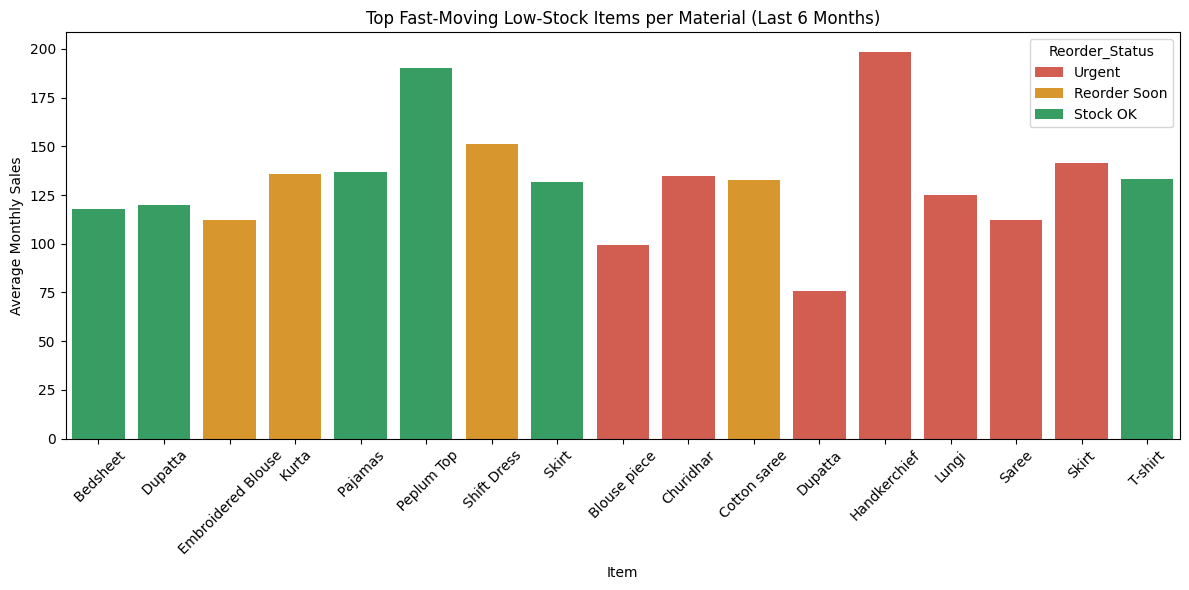

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings from matplotlib
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Set threshold for low stock alerts
low_stock_threshold = 75

# Clean and format columns
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Material'] = df['Material'].str.strip().str.lower()

# Filter data from the last 6 months
recent_data = df[df['Date'] >= df['Date'].max() - pd.DateOffset(months=6)]

# Take top 5 forecasted materials from the prediction results
top_forecasted_materials = [mat for mat, _ in sorted_material_predictions[:5]]

# Filter items with low stock in top forecasted materials
low_stock_data = recent_data[
    (recent_data['Material'].isin(top_forecasted_materials)) &
    (recent_data['Stock_Level'] < low_stock_threshold)
]

# Keep the latest entry for each unique Item + Material + Supplier
latest_stock = (
    low_stock_data.sort_values('Date')
    .drop_duplicates(subset=['Item', 'Material', 'Supplier'], keep='last')
)

# Calculate average sales per item in the last 6 months
avg_sales = (
    recent_data.groupby('Item')['Quantity_Sold']
    .mean()
    .reset_index()
    .rename(columns={'Quantity_Sold': 'Avg_Sales'})
)

# Merge average sales into the latest stock entries
latest_stock = latest_stock.merge(avg_sales, on='Item', how='left')

# Assign reorder status based on stock level
def get_reorder_status(stock):
    if stock < 25:
        return "Urgent"
    elif stock < 45:
        return "Reorder Soon"
    else:
        return "Stock OK"

latest_stock['Reorder_Status'] = latest_stock['Stock_Level'].apply(get_reorder_status)

# Select and sort relevant columns for the recommendation table
recommendations = latest_stock[[
    'Item', 'Material', 'Supplier', 'Stock_Level', 'Avg_Sales', 'Reorder_Status'
]].sort_values(by=['Material', 'Avg_Sales', 'Stock_Level'], ascending=[True, False, True])

# Limit to top 9 items per material
top_9_by_material = (
    recommendations.groupby('Material')
    .apply(lambda grp: grp.nlargest(9, 'Avg_Sales'))
    .reset_index(drop=True)
)

# Remove duplicate items, keeping the one with lowest stock
unique_recommendations = (
    top_9_by_material
    .sort_values(by=['Item', 'Stock_Level', 'Avg_Sales'])
    .drop_duplicates(subset='Item', keep='first')
)

# Define order of status labels for consistent coloring
status_order = ["Urgent", "Reorder Soon", "Stock OK"]
unique_recommendations['Reorder_Status'] = pd.Categorical(
    unique_recommendations['Reorder_Status'],
    categories=status_order,
    ordered=True
)

# Show the final table
print("\nTop 9 Unique Recommended Items Per Forecasted Material (Last 6 Months):\n")
print(unique_recommendations.to_markdown(index=False))

# Bar plot to visualize average sales with status coloring
palette = {
    "Urgent": "#e74c3c",
    "Reorder Soon": "#f39c12",
    "Stock OK": "#27ae60"
}

plt.figure(figsize=(12, 6))
sns.barplot(
    data=unique_recommendations,
    x='Item', y='Avg_Sales',
    hue='Reorder_Status', dodge=False, palette=palette
)
plt.title("Top Fast-Moving Low-Stock Items per Material (Last 6 Months)")
plt.xlabel("Item")
plt.ylabel("Average Monthly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("cell12_predicted_materials.png")

# Save the final result to Excel
unique_recommendations.to_excel("Top9_Unique_Items_Per_Material_Last6Months.xlsx", index=False)
print("\nExcel file saved as 'Top9_Unique_Items_Per_Material_Last6Months.xlsx'")


In [1]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


NameError: name 'y_test' is not defined